# 🛰️ SCIC — Sistema de Comunicação Interplanetária da Colônia
### Atividade Integradora · Fase 6 · Colônia **Aurora Siger**

**Equipe:** AI Team

| Integrante | RM |
|---|---|
| Antuny Marques de Menezes | 572105 |
| Éric Yuiti Nissi | 573495 |
| Vinícius Pelogia do Nascimento | 572675 |


O SCIC é um protótipo em Python que **organiza os dados operacionais e de comunicação** da colônia, **avalia a confiabilidade das previsões de latência**, **prioriza alertas críticos com heap**, permite **buscas por prefixo com trie** e gera uma **análise final de apoio à decisão**.

| Seção | Conteúdo | Fluxo sugerido (Figura 1) |
|---|---|---|
| 0 | Contexto e configuração | — |
| 1 | Leitura e limpeza dos dados | ① Coletar dados simulados · ② Organizar arquivos |
| 2 | Análise exploratória | ② Organizar arquivos |
| 3 | Indicadores operacionais e de comunicação | ③ Calcular indicadores |
| 4 | Erro absoluto, erro relativo e ponto flutuante | ③ Calcular indicadores |
| 5 | Simulação numérica (método de Euler) | ③ Calcular indicadores |
| 6 | Modelo de previsão e métricas (MAE, MSE, RMSE, R², baseline, AIC/BIC) | ④ Avaliar modelo |
| 7 | Priorização de alertas com **heap** | ⑤ Priorizar e consultar |
| 8 | Busca por prefixo com **trie** | ⑤ Priorizar e consultar |
| 9 | Dispositivos, bases numéricas e eletricidade | — |
| 10 | Sistema integrado e **menu de navegação** | — |
| 11 | Análise final, gerenciamento inteligente e reflexão social | ⑥ Gerar relatório |

> **Como executar:** abra este notebook na mesma pasta do arquivo `dados_aurora_siger.csv` e use **Kernel → Restart & Run All**. Os gráficos são salvos automaticamente em `graficos_ou_imagens/`.

## 0. Contexto: a comunicação interplanetária da Aurora Siger

A Aurora Siger é uma colônia em Marte formada por **12 módulos** (habitação, agricultura, comunicação, laboratórios, suporte médico, armazenamento de dados, energia, comando e controle). Todos eles trocam dados com a **Comunicação Central**, e a colônia fala com a Terra por meio do enlace da **Comunicação Orbital**, que usa um satélite retransmissor.

Existem dois tipos de atraso na comunicação:

1. **Atraso da luz entre Marte e a Terra:** varia de cerca de **3 a 22 minutos**, conforme a posição dos planetas. Esse atraso é físico, ninguém consegue reduzi-lo. Por isso, a colônia precisa tomar decisões **localmente e com autonomia**.
2. **Latência da rede local da colônia (em ms):** é o tempo que um módulo leva para entregar seus dados à central ou ao satélite. **Ela pode piorar** com tráfego alto, sinal fraco, superaquecimento ou **tempestades de poeira**. **É esta latência que o SCIC monitora.**

A colônia já tinha uma fórmula simples para **prever** a latência de cada módulo (`latencia_prevista_ms`). O SCIC compara essa previsão com o valor **observado** pelos sensores, verifica quando a previsão falha, treina um modelo melhor e organiza os alertas para a equipe humana agir primeiro no que é mais urgente.

> **Base simulada:** os dados foram gerados pela equipe com o script `gerar_dados_aurora_siger.py` (semente fixa = 42, reprodutível). São 30 ciclos (1 ciclo = 1 *sol*, o dia marciano de cerca de 24h39min). Uma **tempestade de poeira** atinge a colônia entre os ciclos 12 e 16.

In [1]:
# ==== 0. Configuração do ambiente ====
# Bibliotecas padrão do Python
import heapq          # heap pronto do Python (usado só para conferir o nosso heap)
import math
import random
import time
import unicodedata    # usado para remover acentos na trie
from pathlib import Path

# Bibliotecas estudadas na fase
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42                                   # semente fixa: resultados reprodutíveis
ARQUIVO_DADOS = Path("dados_aurora_siger.csv")
PASTA_GRAFICOS = Path("graficos_ou_imagens")
PASTA_GRAFICOS.mkdir(exist_ok=True)

# Limites de erro relativo definidos pela equipe (justificativa na seção 4)
LIMITE_ERRO_ACEITAVEL = 0.10                # até 10%  -> aceitável
LIMITE_ERRO_CRITICO = 0.25                  # acima de 25% -> crítico
HORAS_POR_SOL = 24.65                       # duração aproximada de 1 sol

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)


def salvar_grafico(nome_arquivo):
    """Ajusta o layout, salva a figura atual em graficos_ou_imagens/ e a exibe."""
    caminho = PASTA_GRAFICOS / nome_arquivo
    plt.tight_layout()
    plt.savefig(caminho, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"[gráfico salvo em {caminho}]")


print(f"Ambiente pronto | pandas {pd.__version__} | numpy {np.__version__}")

Ambiente pronto | pandas 3.0.1 | numpy 2.4.3


## 1. Leitura e limpeza dos dados

Cada linha do arquivo `dados_aurora_siger.csv` é **um registro de um módulo em um ciclo**:

| Coluna | Significado |
|---|---|
| `ciclo`, `data_registro` | Ciclo (sol) da missão e data terrestre de referência |
| `modulo`, `tipo_modulo` | Nome e tipo do módulo |
| `codigo_sensor` | Código hexadecimal do sensor de comunicação (formato `0xTMSS`, ver seção 9) |
| `nivel_prioridade` | Essencialidade do módulo (1 = baixa, 5 = vital) |
| `carga_trafego_mbps` | Volume de dados trafegando no enlace |
| `qualidade_sinal_pct` | Qualidade do sinal (0 a 100%) |
| `temperatura_equip_c` | Temperatura do equipamento de comunicação |
| `tempestade_poeira` | 1 = ciclo com tempestade, 0 = normal |
| `latencia_prevista_ms` | Latência estimada pela fórmula antiga da colônia |
| `latencia_observada_ms` | Latência medida pelo sensor (valor real) |
| `tensao_v`, `corrente_a`, `consumo_kwh` | Alimentação elétrica e consumo do equipamento |
| `status_operacional`, `mensagem_alerta` | Situação do módulo (ativo, manutenção ou alerta) e resumo do alerta |

Dados reais quase nunca chegam perfeitos. Antes de analisar, verificamos se há **valores faltantes, duplicados e textos inconsistentes**.

In [2]:
# ==== 1.1 Leitura do arquivo CSV com Pandas ====
def carregar_dados(caminho=ARQUIVO_DADOS):
    """Lê o CSV da colônia e informa quantos registros foram carregados."""
    caminho = Path(caminho)
    if not caminho.exists():
        raise FileNotFoundError(f"Arquivo '{caminho}' não encontrado. Ele deve estar na mesma pasta do notebook.")
    dados = pd.read_csv(caminho, encoding="utf-8")
    print(f"{len(dados)} registros e {dados.shape[1]} colunas carregados de '{caminho}'.")
    return dados


df_bruto = carregar_dados()
df_bruto.head()

363 registros e 17 colunas carregados de 'dados_aurora_siger.csv'.


,ciclo,data_registro,modulo,tipo_modulo,codigo_sensor,nivel_prioridade,carga_trafego_mbps,qualidade_sinal_pct,temperatura_equip_c,tempestade_poeira,latencia_prevista_ms,latencia_observada_ms,tensao_v,corrente_a,consumo_kwh,status_operacional,mensagem_alerta
0,1,2026-09-01,Agricultura Hidropônica,agricultura,0x2103,4,12.93,92.9,26.3,0,71.5,69.2,23.94,2.44,0.977,ativo,Sem alerta
1,1,2026-09-01,Armazenamento de Dados,armazenamento de dados,0x61D4,4,23.50,94.2,27.6,0,46.7,46.6,24.06,3.10,1.307,ativo,Sem alerta
2,1,2026-09-01,Comando Principal,comando,0x81A0,5,35.08,92.8,25.3,0,31.2,31.4,11.74,3.14,0.721,ativo,Sem alerta
3,1,2026-09-01,Comunicação Central,comunicação,0x310A,5,43.50,94.0,28.7,0,37.8,39.7,47.63,4.33,3.662,ativo,Sem alerta
4,1,2026-09-01,Comunicação Orbital,comunicação,0x32F1,5,37.80,90.9,23.7,0,215.6,225.2,48.39,4.92,4.526,ativo,Sem alerta


In [3]:
# ==== 1.2 Diagnóstico: o que precisa ser limpo? ====
faltantes = df_bruto.isna().sum()
print("Valores faltantes por coluna:")
print(faltantes[faltantes > 0].to_string())
print(f"\nLinhas duplicadas: {df_bruto.duplicated().sum()}")
print("\nValores encontrados em 'status_operacional' (repare nas variações de escrita):")
print(df_bruto["status_operacional"].value_counts().to_string())

Valores faltantes por coluna:
latencia_observada_ms    6

Linhas duplicadas: 3

Valores encontrados em 'status_operacional' (repare nas variações de escrita):
status_operacional
ativo         277
alerta         69
manutenção      9
ATIVO           5
 Ativo          2
ALERTA          1


In [4]:
# ==== 1.3 Limpeza ====
def limpar_dados(dados):
    """Aplica as regras de limpeza e devolve um NOVO DataFrame (o original não é alterado)."""
    limpo = dados.copy()
    n_inicial = len(limpo)

    # Regra 1: remove registros duplicados (a mesma mensagem recebida duas vezes pela rede)
    limpo = limpo.drop_duplicates()
    n_duplicados = n_inicial - len(limpo)

    # Regra 2: padroniza textos (sem espaços nas pontas e tudo em minúsculas)
    limpo["status_operacional"] = limpo["status_operacional"].str.strip().str.lower()

    # Regra 3: remove registros sem latência observada.
    # Sem o valor real não é possível calcular erro nem treinar o modelo.
    # Inventar um valor (imputação) poderia esconder justamente uma falha do sensor.
    n_antes = len(limpo)
    limpo = limpo.dropna(subset=["latencia_observada_ms"])
    n_sem_latencia = n_antes - len(limpo)

    # Regra 4: converte a data de texto para o tipo datetime
    limpo["data_registro"] = pd.to_datetime(limpo["data_registro"])

    print(f"Duplicados removidos: {n_duplicados}")
    print(f"Registros sem latência observada removidos: {n_sem_latencia}")
    print(f"Registros válidos: {len(limpo)} de {n_inicial} ({len(limpo) / n_inicial:.1%})")
    return limpo.reset_index(drop=True)


df = limpar_dados(df_bruto)
print("\nStatus após a padronização:")
print(df["status_operacional"].value_counts().to_string())

Duplicados removidos: 3
Registros sem latência observada removidos: 6
Registros válidos: 354 de 363 (97.5%)

Status após a padronização:
status_operacional
ativo         277
alerta         69
manutenção      8


## 2. Análise exploratória

Primeiro, uma visão geral dos números. Depois, gráficos para entender o comportamento da latência por módulo e ao longo do tempo.

In [5]:
# ==== 2.1 Estatísticas descritivas ====
CICLOS_TEMPESTADE = sorted(df.loc[df["tempestade_poeira"] == 1, "ciclo"].unique())
print(f"Ciclos analisados: {df['ciclo'].min()} a {df['ciclo'].max()} | Módulos: {df['modulo'].nunique()} "
      f"| Tempestade de poeira nos ciclos: {CICLOS_TEMPESTADE[0]} a {CICLOS_TEMPESTADE[-1]}")
df.describe().round(2).T

Ciclos analisados: 1 a 30 | Módulos: 12 | Tempestade de poeira nos ciclos: 12 a 16


,count,mean,min,25%,50%,75%,max,std
ciclo,354.0,15.55,1.0,8.0,16.0,23.0,30.0,8.72
data_registro,354,2026-09-15 13:13:13.220339,2026-09-01 00:00:00,2026-09-08 00:00:00,2026-09-16 00:00:00,2026-09-23 00:00:00,2026-09-30 00:00:00,NaN
nivel_prioridade,354.0,3.99,2.0,3.0,4.0,5.0,5.0,1.16
carga_trafego_mbps,354.0,29.61,2.1,12.33,21.46,39.12,119.95,24.68
qualidade_sinal_pct,354.0,89.62,61.2,89.43,92.25,94.0,99.3,7.44
temperatura_equip_c,354.0,26.85,15.9,24.4,27.0,29.3,37.8,3.78
tempestade_poeira,354.0,0.17,0.0,0.0,0.0,0.0,1.0,0.37
latencia_prevista_ms,354.0,70.6,29.6,41.52,54.6,75.65,252.9,51.62
latencia_observada_ms,354.0,87.24,26.5,44.65,63.1,92.0,376.0,66.17
tensao_v,354.0,25.86,10.79,22.84,23.94,24.38,50.09,10.73


In [6]:
# ==== 2.2 Resumo por tipo de módulo ====
resumo_tipo = (df.groupby("tipo_modulo")
                 .agg(registros=("modulo", "size"),
                      latencia_media_ms=("latencia_observada_ms", "mean"),
                      qualidade_media_pct=("qualidade_sinal_pct", "mean"),
                      carga_media_mbps=("carga_trafego_mbps", "mean"))
                 .round(1)
                 .sort_values("latencia_media_ms", ascending=False))
resumo_tipo

,registros,latencia_media_ms,qualidade_media_pct,carga_media_mbps
tipo_modulo,,,,
comunicação,60,153.9,89.7,70.2
laboratório,60,105.4,89.1,21.9
agricultura,30,102.4,88.7,9.0
energia,29,76.9,89.6,5.9
habitação,60,69.7,90.0,14.6
armazenamento de dados,29,57.8,90.9,46.1
suporte médico,29,51.7,89.5,23.2
controle,29,51.2,89.8,17.4
comando,28,42.1,89.3,40.2


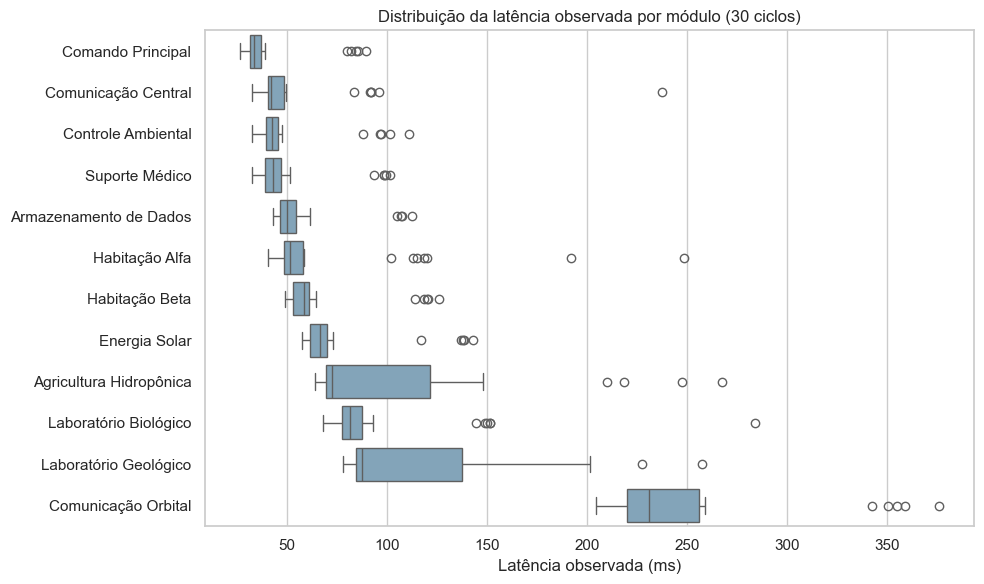

[gráfico salvo em graficos_ou_imagens\01_latencia_por_modulo.png]


In [7]:
# ==== 2.3 Gráfico: distribuição da latência por módulo ====
ordem = df.groupby("modulo")["latencia_observada_ms"].median().sort_values().index
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, y="modulo", x="latencia_observada_ms", order=ordem, color="#7aa6c2")
plt.title("Distribuição da latência observada por módulo (30 ciclos)")
plt.xlabel("Latência observada (ms)")
plt.ylabel("")
salvar_grafico("01_latencia_por_modulo.png")

**Leitura do gráfico:** cada módulo tem uma **escala de latência diferente**. A Comunicação Orbital fica perto de 200 ms, porque o enlace vai até o satélite. O Comando Principal fica perto de 30 ms. Os pontos isolados à direita (*outliers*) são **picos** e **ciclos de tempestade**. Como as escalas são tão diferentes, só o **erro relativo** permite comparar os módulos de forma justa (seção 4).

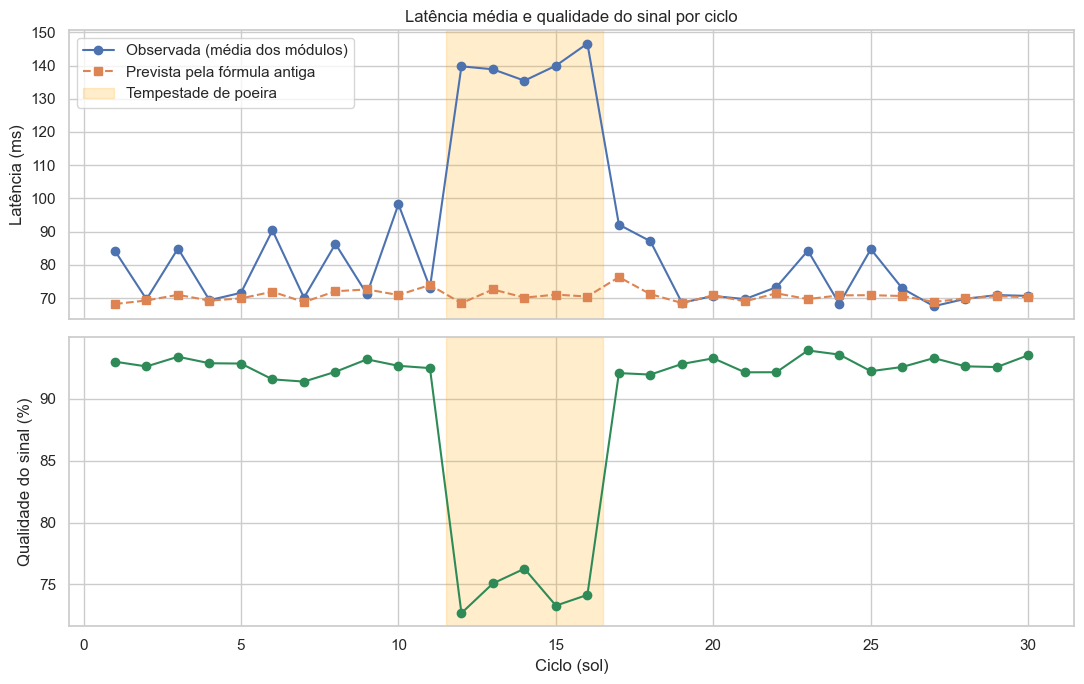

[gráfico salvo em graficos_ou_imagens\02_evolucao_por_ciclo.png]


In [8]:
# ==== 2.4 Gráfico: evolução por ciclo (efeito da tempestade de poeira) ====
por_ciclo = df.groupby("ciclo")[["latencia_prevista_ms", "latencia_observada_ms", "qualidade_sinal_pct"]].mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax1.plot(por_ciclo.index, por_ciclo["latencia_observada_ms"], marker="o", label="Observada (média dos módulos)")
ax1.plot(por_ciclo.index, por_ciclo["latencia_prevista_ms"], marker="s", linestyle="--", label="Prevista pela fórmula antiga")
ax2.plot(por_ciclo.index, por_ciclo["qualidade_sinal_pct"], marker="o", color="seagreen")
for ax in (ax1, ax2):
    ax.axvspan(CICLOS_TEMPESTADE[0] - 0.5, CICLOS_TEMPESTADE[-1] + 0.5, color="orange", alpha=0.2,
               label="Tempestade de poeira")
ax1.set_ylabel("Latência (ms)")
ax1.set_title("Latência média e qualidade do sinal por ciclo")
ax1.legend(loc="upper left")
ax2.set_ylabel("Qualidade do sinal (%)")
ax2.set_xlabel("Ciclo (sol)")
salvar_grafico("02_evolucao_por_ciclo.png")

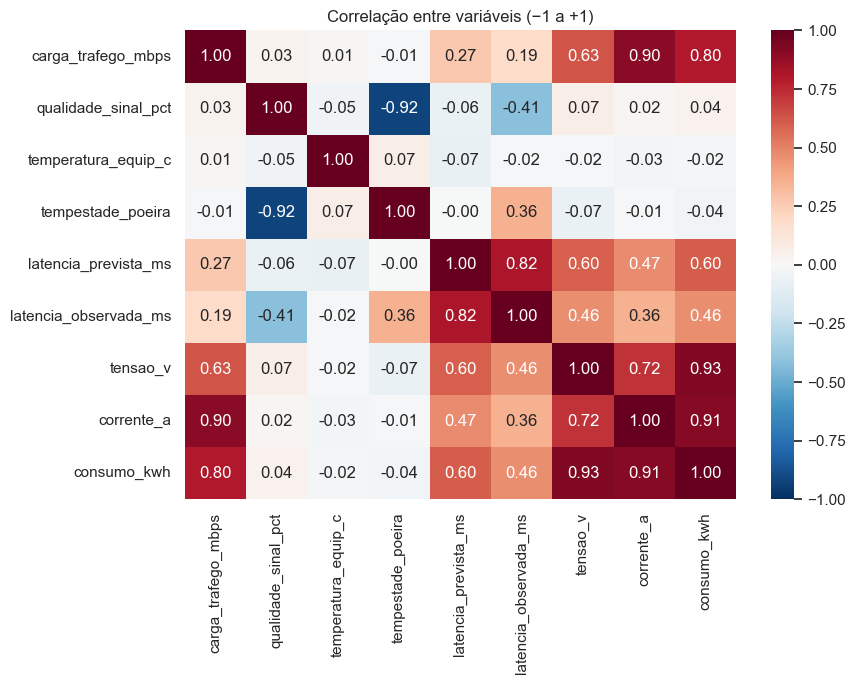

[gráfico salvo em graficos_ou_imagens\03_correlacao.png]


In [9]:
# ==== 2.5 Gráfico: correlação entre as variáveis numéricas ====
colunas_numericas = ["carga_trafego_mbps", "qualidade_sinal_pct", "temperatura_equip_c", "tempestade_poeira",
                     "latencia_prevista_ms", "latencia_observada_ms", "tensao_v", "corrente_a", "consumo_kwh"]
plt.figure(figsize=(9, 7))
sns.heatmap(df[colunas_numericas].corr(), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("Correlação entre variáveis (−1 a +1)")
salvar_grafico("03_correlacao.png")

**Leitura:** a latência observada tem correlação **positiva** com a tempestade e **negativa** com a qualidade do sinal (sinal pior → latência maior). Essas variáveis entram no modelo de previsão (seção 6). Correlação não prova causa, mas indica por onde começar a investigar.

## 3. Indicadores operacionais e de comunicação

Indicadores são números que resumem a "saúde" da rede:

| Indicador | Fórmula | Para que serve |
|---|---|---|
| **Potência elétrica** | P = V × I (watts) | Quanto o equipamento de comunicação consome naquele instante |
| **Eficiência de comunicação** | Mbps ÷ W | Quantos dados são transmitidos para cada watt gasto (sustentabilidade) |
| **Disponibilidade** | % de registros com status "ativo" | Quanto tempo o módulo funcionou sem problemas |
| **Latência média e máxima** | média e máximo da latência observada | Desempenho típico e pior caso |
| **Quantidade de alertas** | contagem de status "alerta" | Módulos mais problemáticos |

In [10]:
# ==== 3.1 Cálculo dos indicadores por registro ====
def adicionar_indicadores(dados):
    """Cria as colunas de potência (P = V × I) e eficiência (Mbps por watt)."""
    dados = dados.copy()
    dados["potencia_w"] = dados["tensao_v"] * dados["corrente_a"]
    dados["eficiencia_mbps_por_w"] = dados["carga_trafego_mbps"] / dados["potencia_w"]
    return dados


df = adicionar_indicadores(df)

# ==== 3.2 Indicadores por módulo ====
indicadores = (df.groupby("modulo")
                 .agg(tipo=("tipo_modulo", "first"),
                      latencia_media_ms=("latencia_observada_ms", "mean"),
                      latencia_max_ms=("latencia_observada_ms", "max"),
                      disponibilidade_pct=("status_operacional", lambda s: (s == "ativo").mean() * 100),
                      alertas=("status_operacional", lambda s: (s == "alerta").sum()),
                      potencia_media_w=("potencia_w", "mean"),
                      consumo_total_kwh=("consumo_kwh", "sum"),
                      eficiencia_mbps_por_w=("eficiencia_mbps_por_w", "mean"))
                 .round(2)
                 .sort_values(["alertas", "latencia_media_ms"], ascending=False))
indicadores

,tipo,latencia_media_ms,latencia_max_ms,disponibilidade_pct,alertas,potencia_media_w,consumo_total_kwh,eficiencia_mbps_por_w
modulo,,,,,,,,
Laboratório Geológico,laboratório,112.48,257.5,70.00,8,46.51,25.45,0.49
Agricultura Hidropônica,agricultura,102.44,267.4,73.33,8,56.25,29.53,0.16
Habitação Alfa,habitação,72.36,248.4,73.33,7,49.59,26.96,0.29
Laboratório Biológico,laboratório,98.41,283.9,80.00,6,47.59,25.28,0.43
Comunicação Central,comunicação,56.35,237.6,76.67,6,243.19,129.70,0.33
Comunicação Orbital,comunicação,251.49,376.0,76.67,5,256.74,138.52,0.23
Energia Solar,energia,76.95,143.0,82.76,5,31.56,16.04,0.18
Habitação Beta,habitação,66.99,125.9,80.00,5,47.05,24.99,0.31
Suporte Médico,suporte médico,51.67,101.4,82.76,5,58.48,30.62,0.39


In [11]:
# ==== 3.3 Indicadores gerais da colônia ====
normal = df[df["tempestade_poeira"] == 0]
tempestade = df[df["tempestade_poeira"] == 1]
total_alertas = (df["status_operacional"] == "alerta").sum()

print("=== PAINEL DE INDICADORES DA AURORA SIGER ===")
print(f"Disponibilidade geral da rede ........ {(df['status_operacional'] == 'ativo').mean():.1%}")
print(f"Registros em alerta .................. {total_alertas} ({total_alertas / len(df):.1%})")
print(f"Latência média (ciclos normais) ...... {normal['latencia_observada_ms'].mean():.1f} ms")
print(f"Latência média (tempestade) .......... {tempestade['latencia_observada_ms'].mean():.1f} ms "
      f"(+{tempestade['latencia_observada_ms'].mean() / normal['latencia_observada_ms'].mean() - 1:.0%})")
print(f"Qualidade média do sinal (normal) .... {normal['qualidade_sinal_pct'].mean():.1f}%")
print(f"Qualidade média do sinal (tempestade)  {tempestade['qualidade_sinal_pct'].mean():.1f}%")
print(f"Potência média por equipamento ....... {df['potencia_w'].mean():.1f} W")
print(f"Consumo total da comunicação (30 sóis) {df['consumo_kwh'].sum():.1f} kWh")
print(f"Módulo com mais alertas .............. {indicadores.index[0]} ({indicadores['alertas'].iloc[0]} alertas)")

=== PAINEL DE INDICADORES DA AURORA SIGER ===
Disponibilidade geral da rede ........ 78.2%
Registros em alerta .................. 69 (19.5%)
Latência média (ciclos normais) ...... 76.7 ms
Latência média (tempestade) .......... 140.1 ms (+83%)
Qualidade média do sinal (normal) .... 92.7%
Qualidade média do sinal (tempestade)  74.3%
Potência média por equipamento ....... 83.0 W
Consumo total da comunicação (30 sóis) 524.4 kWh
Módulo com mais alertas .............. Laboratório Geológico (8 alertas)


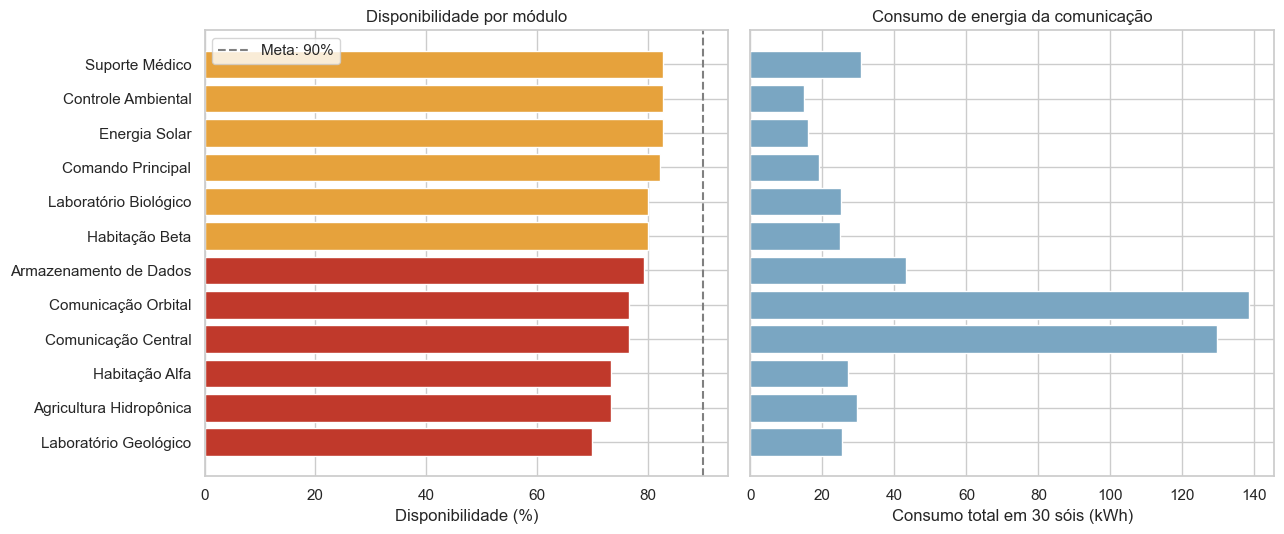

[gráfico salvo em graficos_ou_imagens\04_disponibilidade_consumo.png]


In [12]:
# ==== 3.4 Gráfico: disponibilidade e consumo por módulo ====
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
ind_ordenado = indicadores.sort_values("disponibilidade_pct")
cores = ["#c0392b" if v < 80 else "#e6a23c" if v < 90 else "#3d8b5f" for v in ind_ordenado["disponibilidade_pct"]]
ax1.barh(ind_ordenado.index, ind_ordenado["disponibilidade_pct"], color=cores)
ax1.axvline(90, color="gray", linestyle="--", label="Meta: 90%")
ax1.set_xlabel("Disponibilidade (%)")
ax1.set_title("Disponibilidade por módulo")
ax1.legend()
ax2.barh(ind_ordenado.index, ind_ordenado["consumo_total_kwh"], color="#7aa6c2")
ax2.set_xlabel("Consumo total em 30 sóis (kWh)")
ax2.set_title("Consumo de energia da comunicação")
salvar_grafico("04_disponibilidade_consumo.png")

## 4. Análise numérica: erro absoluto, erro relativo e ponto flutuante

Vamos comparar a latência **prevista** pela fórmula antiga com a latência **observada**:

- **Erro absoluto** = |observado − previsto| → mostra **quantos ms** a previsão errou.
- **Erro relativo** = |observado − previsto| ÷ |observado| → mostra **qual fração** do valor real a previsão errou. Usamos o valor **observado** como referência porque ele é o "valor verdadeiro" medido pelo sensor.

**Por que precisamos dos dois?** Errar 30 ms no enlace orbital (~200 ms) é pouco, cerca de 15%. Errar 30 ms no Comando Principal (~25 ms) é mais que o próprio valor. O erro relativo permite **comparar módulos de escalas diferentes**.

**Critério da equipe para o erro relativo:**

| Faixa | Classificação | Justificativa no contexto da colônia |
|---|---|---|
| ≤ 10% | ✅ aceitável | Variação natural do enlace (ruído do sensor, pequenas oscilações de tráfego) |
| 10% a 25% | ⚠️ atenção | A previsão começa a falhar, então vale monitorar o módulo de perto |
| > 25% | 🚨 crítico | A previsão não é confiável e o módulo pode atrasar comandos vitais. Deve virar alerta |

In [13]:
# ==== 4.1 Funções de erro ====
def erro_absoluto(previsto, observado):
    """|observado − previsto| (mesma unidade da variável, aqui ms)."""
    return abs(observado - previsto)


def erro_relativo(previsto, observado):
    """|observado − previsto| / |observado| (adimensional; multiplique por 100 para %)."""
    return abs(observado - previsto) / abs(observado)


def classificar_erro(erro_rel):
    """Classifica o erro relativo segundo os limites definidos pela equipe."""
    if erro_rel <= LIMITE_ERRO_ACEITAVEL:
        return "aceitável"
    if erro_rel <= LIMITE_ERRO_CRITICO:
        return "atenção"
    return "crítico"


# Exemplo passo a passo: dois módulos de escalas diferentes no mesmo ciclo de tempestade
ciclo_exemplo = CICLOS_TEMPESTADE[2]
for nome in ["Comunicação Orbital", "Comando Principal"]:
    r = df[(df["modulo"] == nome) & (df["ciclo"] == ciclo_exemplo)].iloc[0]
    ea = erro_absoluto(r["latencia_prevista_ms"], r["latencia_observada_ms"])
    er = erro_relativo(r["latencia_prevista_ms"], r["latencia_observada_ms"])
    print(f"{nome} (ciclo {ciclo_exemplo}):")
    print(f"  previsto = {r['latencia_prevista_ms']} ms | observado = {r['latencia_observada_ms']} ms")
    print(f"  erro absoluto = |{r['latencia_observada_ms']} − {r['latencia_prevista_ms']}| = {ea:.1f} ms")
    print(f"  erro relativo = {ea:.1f} / {r['latencia_observada_ms']} = {er:.3f} = {er:.1%} -> {classificar_erro(er)}\n")

Comunicação Orbital (ciclo 14):
  previsto = 237.6 ms | observado = 358.8 ms
  erro absoluto = |358.8 − 237.6| = 121.2 ms
  erro relativo = 121.2 / 358.8 = 0.338 = 33.8% -> crítico

Comando Principal (ciclo 14):
  previsto = 32.3 ms | observado = 84.5 ms
  erro absoluto = |84.5 − 32.3| = 52.2 ms
  erro relativo = 52.2 / 84.5 = 0.618 = 61.8% -> crítico



**Interpretação do exemplo:** no mesmo ciclo, o enlace orbital tem **erro absoluto maior**, porém **erro relativo menor**. Se olhássemos só os milissegundos, poderíamos achar que o enlace orbital é o mais problemático. Proporcionalmente, porém, o Comando Principal está muito pior, e ele é um módulo vital.

In [14]:
# ==== 4.2 Erros para toda a base ====
def adicionar_erros(dados):
    """Cria as colunas de erro absoluto, erro relativo e classe do erro."""
    dados = dados.copy()
    dados["erro_absoluto_ms"] = erro_absoluto(dados["latencia_prevista_ms"], dados["latencia_observada_ms"])
    dados["erro_relativo"] = erro_relativo(dados["latencia_prevista_ms"], dados["latencia_observada_ms"])
    dados["classe_erro"] = dados["erro_relativo"].apply(classificar_erro)
    return dados


df = adicionar_erros(df)

print("Classificação dos erros: ciclos normais x tempestade (% das linhas):")
tabela_classes = pd.crosstab(df["tempestade_poeira"].map({0: "normal", 1: "tempestade"}),
                             df["classe_erro"], normalize="index").mul(100).round(1)
print(tabela_classes[["aceitável", "atenção", "crítico"]].to_string())

erros_modulo = (df.groupby("modulo")
                  .agg(erro_abs_medio_ms=("erro_absoluto_ms", "mean"),
                       erro_rel_medio_pct=("erro_relativo", lambda s: s.mean() * 100),
                       erro_rel_mediano_pct=("erro_relativo", lambda s: s.median() * 100),
                       registros_criticos=("classe_erro", lambda s: (s == "crítico").sum()))
                  .round(1)
                  .sort_values("erro_rel_medio_pct", ascending=False))
erros_modulo

Classificação dos erros: ciclos normais x tempestade (% das linhas):
classe_erro        aceitável  atenção  crítico
tempestade_poeira                             
normal                  78.6     17.3      4.1
tempestade               0.0      0.0    100.0


,erro_abs_medio_ms,erro_rel_medio_pct,erro_rel_mediano_pct,registros_criticos
modulo,,,,
Agricultura Hidropônica,34.3,20.0,6.1,8
Habitação Alfa,24.4,19.6,8.6,7
Comunicação Central,17.0,17.0,5.1,6
Comando Principal,11.4,17.0,9.2,5
Laboratório Geológico,29.2,17.0,5.3,8
Suporte Médico,12.7,16.7,8.7,6
Controle Ambiental,12.6,16.4,6.6,6
Habitação Beta,13.8,14.6,7.5,5
Laboratório Biológico,21.7,14.2,6.0,6


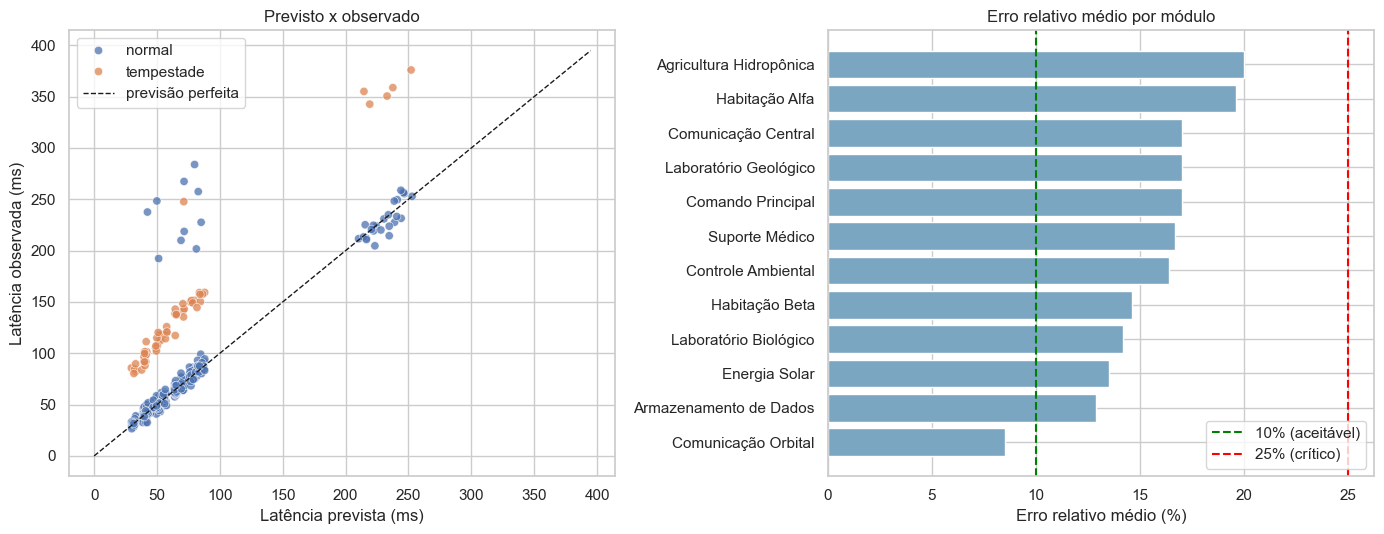

[gráfico salvo em graficos_ou_imagens\05_erros_previsao.png]


In [15]:
# ==== 4.3 Gráficos de erro ====
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# (a) Previsto x observado: pontos sobre a linha tracejada = previsão perfeita
sns.scatterplot(data=df, x="latencia_prevista_ms", y="latencia_observada_ms",
                hue=df["tempestade_poeira"].map({0: "normal", 1: "tempestade"}),
                palette={"normal": "#4c72b0", "tempestade": "#dd8452"}, ax=ax1, alpha=0.75)
lim = [0, df[["latencia_prevista_ms", "latencia_observada_ms"]].max().max() * 1.05]
ax1.plot(lim, lim, "k--", linewidth=1, label="previsão perfeita")
ax1.set_xlabel("Latência prevista (ms)")
ax1.set_ylabel("Latência observada (ms)")
ax1.set_title("Previsto x observado")
ax1.legend(title="")

# (b) Erro relativo médio por módulo, com as faixas de decisão
ordem_erro = erros_modulo.sort_values("erro_rel_medio_pct")
ax2.barh(ordem_erro.index, ordem_erro["erro_rel_medio_pct"], color="#7aa6c2")
ax2.axvline(LIMITE_ERRO_ACEITAVEL * 100, color="green", linestyle="--", label="10% (aceitável)")
ax2.axvline(LIMITE_ERRO_CRITICO * 100, color="red", linestyle="--", label="25% (crítico)")
ax2.set_xlabel("Erro relativo médio (%)")
ax2.set_title("Erro relativo médio por módulo")
ax2.legend()
salvar_grafico("05_erros_previsao.png")

### 4.4 Ponto flutuante e precisão numérica

O computador guarda números reais em **ponto flutuante** (padrão IEEE 754), usando um número fixo de bits. Por isso, muitos decimais **não são representados exatamente**. Para o SCIC, isso tem três consequências práticas:

1. **Nunca comparar números reais com `==`.** Use uma tolerância, por exemplo `math.isclose`.
2. **Somas longas acumulam erro.** Isso é ainda mais grave em precisão simples (`float32`, comum em microcontroladores de sensores).
3. **O arredondamento dos dados também gera erro.** O CSV guarda a latência com 1 casa decimal, então cada valor pode ter até ±0,05 ms de erro de arredondamento.

In [16]:
# ==== 4.4 Demonstrações de ponto flutuante ====
print("1) 0.1 + 0.2 =", 0.1 + 0.2)
print("   0.1 + 0.2 == 0.3 ?", 0.1 + 0.2 == 0.3, "| math.isclose(0.1 + 0.2, 0.3) ?", math.isclose(0.1 + 0.2, 0.3))

print(f"\n2) Epsilon da máquina (menor diferença relativa representável):")
print(f"   float64: {np.finfo(np.float64).eps:.2e}  (~16 dígitos significativos)")
print(f"   float32: {np.finfo(np.float32).eps:.2e}  (~7 dígitos significativos)")

# Soma acumulada, uma leitura por vez, como faria um sensor que acumula 1 milhão de leituras de 0,1 ms
n = 1_000_000
soma32 = np.cumsum(np.full(n, 0.1, dtype=np.float32))[-1]
soma64 = np.cumsum(np.full(n, 0.1, dtype=np.float64))[-1]
valor_exato = n * 0.1
print(f"\n3) Somar 0,1 ms um milhão de vezes (valor exato = {valor_exato:.1f} ms):")
print(f"   float32 -> {soma32:.4f} ms | erro absoluto = {erro_absoluto(soma32, valor_exato):.4f} ms "
      f"| erro relativo = {erro_relativo(soma32, valor_exato):.2e}")
print(f"   float64 -> {soma64:.4f} ms | erro absoluto = {erro_absoluto(soma64, valor_exato):.2e} ms "
      f"| erro relativo = {erro_relativo(soma64, valor_exato):.2e}")

lat_min, lat_max = df["latencia_observada_ms"].min(), df["latencia_observada_ms"].max()
print(f"\n4) Arredondamento para 1 casa decimal (erro máximo de ±0,05 ms):")
print(f"   menor latência ({lat_min} ms): erro relativo máximo = {0.05 / lat_min:.3%}")
print(f"   maior latência ({lat_max} ms): erro relativo máximo = {0.05 / lat_max:.4%}")

1) 0.1 + 0.2 = 0.30000000000000004
   0.1 + 0.2 == 0.3 ? False | math.isclose(0.1 + 0.2, 0.3) ? True

2) Epsilon da máquina (menor diferença relativa representável):
   float64: 2.22e-16  (~16 dígitos significativos)
   float32: 1.19e-07  (~7 dígitos significativos)

3) Somar 0,1 ms um milhão de vezes (valor exato = 100000.0 ms):
   float32 -> 100958.3438 ms | erro absoluto = 958.3438 ms | erro relativo = 9.58e-03
   float64 -> 100000.0000 ms | erro absoluto = 1.33e-06 ms | erro relativo = 1.33e-11

4) Arredondamento para 1 casa decimal (erro máximo de ±0,05 ms):
   menor latência (26.5 ms): erro relativo máximo = 0.189%
   maior latência (376.0 ms): erro relativo máximo = 0.0133%


**Conclusão sobre a precisão:** o erro de arredondamento dos dados (no máximo cerca de 0,2%) é **muito menor** que os erros de previsão que estamos analisando (5% a 50%). Portanto, ele **não muda nenhuma conclusão**. Já a soma em `float32` mostra que um sensor simples acumulando leituras por muito tempo pode se afastar do valor real. Por isso, o SCIC faz os cálculos em `float64`, o padrão do NumPy e do Pandas, e compara valores com tolerância.

## 5. Simulação numérica: recuperação do enlace após a tempestade (método de Euler)

Depois que a tempestade termina, o enlace orbital não volta ao normal na hora: a poeira assenta e as antenas são recalibradas aos poucos. Um modelo simples para essa recuperação é a equação diferencial

$$\frac{dL}{dt} = -k\,(L - L_{normal})$$

Ela diz que, quanto mais longe a latência está do normal, mais rápido ela se recupera. A solução exata é $L(t) = L_{normal} + (L_0 - L_{normal})\,e^{-kt}$. Vamos resolvê-la com o **método de Euler** e medir o **erro numérico** em relação à solução exata, com diferentes tamanhos de passo `h`.

> O valor `k = 0,8 por sol` é uma **hipótese da equipe** para ilustrar o método. $L_0$ e $L_{normal}$ vêm dos dados.

In [17]:
# ==== 5.1 Método de Euler ====
def euler(f, y0, t0, t_final, h):
    """Resolve dy/dt = f(t, y) pelo método de Euler: y_{n+1} = y_n + h·f(t_n, y_n)."""
    n_passos = int(round((t_final - t0) / h))   # calcula o nº de passos para não acumular erro em t
    ts = t0 + h * np.arange(n_passos + 1)
    ys = np.empty(n_passos + 1)
    ys[0] = y0
    for i in range(n_passos):
        ys[i + 1] = ys[i] + h * f(ts[i], ys[i])
    return ts, ys


orbital = df[df["modulo"] == "Comunicação Orbital"]
L_NORMAL = orbital.loc[orbital["tempestade_poeira"] == 0, "latencia_observada_ms"].median()
L0 = orbital.loc[orbital["ciclo"] == CICLOS_TEMPESTADE[-1], "latencia_observada_ms"].iloc[0]
K = 0.8          # taxa de recuperação por sol (hipótese)
T_FINAL = 6      # sóis simulados após a tempestade


def taxa_recuperacao(t, L):
    return -K * (L - L_NORMAL)


def solucao_exata(t):
    return L_NORMAL + (L0 - L_NORMAL) * np.exp(-K * t)


print(f"L0 (último ciclo de tempestade) = {L0} ms | L_normal (mediana fora da tempestade) = {L_NORMAL} ms\n")
print(f"{'passo h':>8} | {'L(6) Euler':>11} | {'L(6) exata':>11} | {'erro absoluto':>13} | {'erro relativo':>13}")
resultados_euler = {}
for h in [1.0, 0.5, 0.1]:
    ts, ys = euler(taxa_recuperacao, L0, 0, T_FINAL, h)
    resultados_euler[h] = (ts, ys)
    exato = solucao_exata(T_FINAL)
    print(f"{h:>8} | {ys[-1]:>11.3f} | {exato:>11.3f} | {erro_absoluto(ys[-1], exato):>13.4f} | "
          f"{erro_relativo(ys[-1], exato):>13.2e}")

# Em quanto tempo a latência volta a ficar a menos de 10% do normal? (solução exata)
t_recuperacao = math.log(abs(L0 - L_NORMAL) / (0.10 * L_NORMAL)) / K
print(f"\nTempo estimado para voltar a até 10% do normal: {t_recuperacao:.2f} sóis")

L0 (último ciclo de tempestade) = 350.6 ms | L_normal (mediana fora da tempestade) = 225.2 ms

 passo h |  L(6) Euler |  L(6) exata | erro absoluto | erro relativo
     1.0 |     225.208 |     226.232 |        1.0240 |      4.53e-03
     0.5 |     225.473 |     226.232 |        0.7590 |      3.36e-03
     0.1 |     226.042 |     226.232 |        0.1895 |      8.38e-04

Tempo estimado para voltar a até 10% do normal: 2.15 sóis


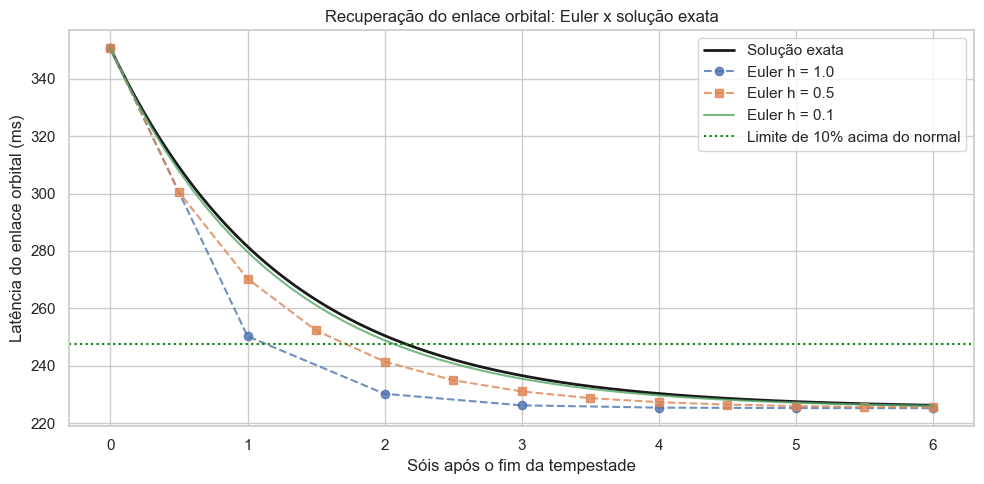

[gráfico salvo em graficos_ou_imagens\06_simulacao_euler.png]


In [18]:
# ==== 5.2 Gráfico da simulação ====
t_fino = np.linspace(0, T_FINAL, 200)
plt.figure(figsize=(10, 5))
plt.plot(t_fino, solucao_exata(t_fino), "k-", linewidth=2, label="Solução exata")
for h, estilo in zip(resultados_euler, ["o--", "s--", "-"]):
    ts, ys = resultados_euler[h]
    plt.plot(ts, ys, estilo, alpha=0.8, label=f"Euler h = {h}")
plt.axhline(L_NORMAL * 1.10, color="green", linestyle=":", label="Limite de 10% acima do normal")
plt.xlabel("Sóis após o fim da tempestade")
plt.ylabel("Latência do enlace orbital (ms)")
plt.title("Recuperação do enlace orbital: Euler x solução exata")
plt.legend()
salvar_grafico("06_simulacao_euler.png")

**Interpretação:** quanto **menor o passo h**, mais perto o método de Euler fica da solução exata. No tempo t = 6, o erro cai de cerca de 1 ms (h = 1) para cerca de 0,2 ms (h = 0,1). Em troca, são necessários 10 vezes mais cálculos. Euler é um método de 1ª ordem: o erro tende a diminuir na mesma proporção de h quando o passo é pequeno. Para o SCIC, essa simulação permite **estimar quando o enlace volta ao normal** e, assim, planejar o retorno das transmissões pesadas para a Terra.

## 6. Modelo simples de previsão e avaliação de performance

**Problema (regressão):** prever a `latencia_observada_ms` de um módulo a partir de condições conhecidas no momento: carga de tráfego, qualidade do sinal, temperatura, ocorrência de tempestade e qual é o módulo.

**Divisão dos dados:**
- **Treino (60%):** o modelo aprende com esses dados.
- **Validação (20%):** usada para escolher o melhor modelo.
- **Teste (20%):** guardado até o final, para medir o desempenho em dados nunca vistos.

**Modelos comparados:**

| Modelo | Ideia |
|---|---|
| **Baseline (média)** | Sempre "chuta" a latência média do treino. Qualquer modelo útil precisa ser **melhor que isso** |
| **Fórmula antiga da colônia** | A coluna `latencia_prevista_ms`, que já existia |
| **Regressão Linear** | Soma ponderada das variáveis (cada uma com seu peso) |
| **Árvore de Decisão + Grid Search** | Regras do tipo "se tempestade e sinal < 80% então…", com os hiperparâmetros escolhidos pelo Grid Search |

**Métricas (Figura 2 do enunciado):**

| Métrica | O que mede | Unidade |
|---|---|---|
| **MAE** (erro absoluto médio) | Em média, quanto o modelo erra | ms |
| **MSE** (erro quadrático médio) | Média dos erros ao quadrado. **Penaliza muito** os erros grandes | ms² |
| **RMSE** (raiz do MSE) | Como o MSE, mas de volta na unidade original | ms |
| **R²** (coeficiente de determinação) | Fração da variação da latência explicada pelo modelo (1 = perfeito, 0 = igual a chutar a média) | — |

In [19]:
# ==== 6.1 Preparação das variáveis ====
VARIAVEIS_NUMERICAS = ["carga_trafego_mbps", "qualidade_sinal_pct", "temperatura_equip_c", "tempestade_poeira"]
ALVO = "latencia_observada_ms"


def montar_X(dados):
    """Monta a matriz de entrada: variáveis numéricas + uma coluna 0/1 para cada módulo (one-hot)."""
    modulos_dummies = pd.get_dummies(dados["modulo"], prefix="mod", dtype=int)
    return pd.concat([dados[VARIAVEIS_NUMERICAS], modulos_dummies], axis=1)


X = montar_X(df)
y = df[ALVO]

# 60% treino | 20% validação | 20% teste
X_temp, X_teste, y_temp, y_teste = train_test_split(X, y, test_size=0.20, random_state=SEED)
X_treino, X_val, y_treino, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=SEED)
print(f"Treino: {len(X_treino)} | Validação: {len(X_val)} | Teste: {len(X_teste)} registros")
print(f"Variáveis de entrada ({X.shape[1]}): {VARIAVEIS_NUMERICAS} + {X.shape[1] - len(VARIAVEIS_NUMERICAS)} colunas de módulo")

Treino: 212 | Validação: 71 | Teste: 71 registros
Variáveis de entrada (16): ['carga_trafego_mbps', 'qualidade_sinal_pct', 'temperatura_equip_c', 'tempestade_poeira'] + 12 colunas de módulo


In [20]:
# ==== 6.2 Função de avaliação ====
def avaliar(y_real, y_previsto):
    """Calcula MAE, MSE, RMSE e R², além da razão RMSE/MAE."""
    mae = mean_absolute_error(y_real, y_previsto)
    mse = mean_squared_error(y_real, y_previsto)
    rmse = math.sqrt(mse)
    return {"MAE (ms)": mae, "MSE (ms²)": mse, "RMSE (ms)": rmse,
            "R²": r2_score(y_real, y_previsto), "RMSE/MAE": rmse / mae}


# ==== 6.3 Treinamento dos modelos ====
baseline = DummyRegressor(strategy="mean").fit(X_treino, y_treino)
linear = LinearRegression().fit(X_treino, y_treino)

grade = {"max_depth": [3, 4, 5, 6, 8, 10, None], "min_samples_leaf": [1, 2, 3, 5, 10]}
busca = GridSearchCV(DecisionTreeRegressor(random_state=SEED), grade,
                     scoring="neg_mean_absolute_error", cv=5)
busca.fit(X_treino, y_treino)
arvore = busca.best_estimator_
print(f"Grid Search testou {len(busca.cv_results_['params'])} combinações com validação cruzada de 5 partes.")
print(f"Melhores hiperparâmetros da árvore: {busca.best_params_}")

modelos = {"Baseline (média)": baseline, "Regressão Linear": linear, "Árvore de Decisão (Grid Search)": arvore}

# ==== 6.4 Comparação na VALIDAÇÃO ====
resultados_val = {nome: avaliar(y_val, m.predict(X_val)) for nome, m in modelos.items()}
resultados_val["Fórmula antiga da colônia"] = avaliar(y_val, df.loc[X_val.index, "latencia_prevista_ms"])
tabela_val = pd.DataFrame(resultados_val).T.round(3).sort_values("MAE (ms)")
print("\nDesempenho no conjunto de VALIDAÇÃO:")
tabela_val

Grid Search testou 35 combinações com validação cruzada de 5 partes.
Melhores hiperparâmetros da árvore: {'max_depth': None, 'min_samples_leaf': 2}

Desempenho no conjunto de VALIDAÇÃO:


,MAE (ms),MSE (ms²),RMSE (ms),R²,RMSE/MAE
Regressão Linear,9.795,330.048,18.167,0.929,1.855
Árvore de Decisão (Grid Search),14.833,903.363,30.056,0.805,2.026
Fórmula antiga da colônia,17.432,1087.004,32.970,0.765,1.891
Baseline (média),47.522,4652.094,68.206,-0.005,1.435


In [21]:
# ==== 6.5 Escolha do modelo e avaliação final no TESTE ====
candidatos = tabela_val.drop(index=["Baseline (média)", "Fórmula antiga da colônia"])
NOME_MELHOR = candidatos["MAE (ms)"].idxmin()
modelo_final = modelos[NOME_MELHOR]
print(f"Modelo escolhido pela validação (menor MAE): {NOME_MELHOR}\n")

resultados_teste = {nome: avaliar(y_teste, m.predict(X_teste)) for nome, m in modelos.items()}
resultados_teste["Fórmula antiga da colônia"] = avaliar(y_teste, df.loc[X_teste.index, "latencia_prevista_ms"])
tabela_teste = pd.DataFrame(resultados_teste).T.round(3).sort_values("MAE (ms)")
print("Desempenho no conjunto de TESTE (dados nunca vistos):")
tabela_teste

Modelo escolhido pela validação (menor MAE): Regressão Linear

Desempenho no conjunto de TESTE (dados nunca vistos):


,MAE (ms),MSE (ms²),RMSE (ms),R²,RMSE/MAE
Regressão Linear,12.929,921.392,30.354,0.807,2.348
Árvore de Decisão (Grid Search),15.825,1271.182,35.654,0.734,2.253
Fórmula antiga da colônia,19.715,1769.761,42.069,0.630,2.134
Baseline (média),46.570,4788.498,69.199,-0.001,1.486


In [22]:
# ==== 6.6 Interpretação automática das métricas ====
def interpretar_metricas(nome, m, m_baseline):
    """Traduz as métricas em frases, mostrando que um único número não basta."""
    print(f"--- {nome} ---")
    print(f"• MAE = {m['MAE (ms)']:.1f} ms: em média, a previsão erra {m['MAE (ms)']:.1f} ms para mais ou para menos.")
    ganho = 1 - m["MAE (ms)"] / m_baseline["MAE (ms)"]
    print(f"• Em relação ao baseline (MAE {m_baseline['MAE (ms)']:.1f} ms), o erro médio caiu {ganho:.0%}.")
    print(f"• RMSE = {m['RMSE (ms)']:.1f} ms, ou seja, {m['RMSE/MAE']:.2f}× o MAE. ", end="")
    if m["RMSE/MAE"] > 1.5:
        print("A diferença é grande: a maioria dos erros é pequena, mas ALGUNS registros têm erros muito grandes.")
    else:
        print("Os erros têm tamanhos parecidos entre si (poucos erros extremos).")
    print(f"• R² = {m['R²']:.3f}: o modelo explica {m['R²']:.1%} da variação da latência. ", end="")
    print("Mesmo assim, ele NÃO é perfeito: um R² alto pode esconder erros grandes em casos raros.\n")


for nome in [NOME_MELHOR, "Fórmula antiga da colônia"]:
    interpretar_metricas(nome, resultados_teste[nome], resultados_teste["Baseline (média)"])

--- Regressão Linear ---
• MAE = 12.9 ms: em média, a previsão erra 12.9 ms para mais ou para menos.
• Em relação ao baseline (MAE 46.6 ms), o erro médio caiu 72%.
• RMSE = 30.4 ms, ou seja, 2.35× o MAE. A diferença é grande: a maioria dos erros é pequena, mas ALGUNS registros têm erros muito grandes.
• R² = 0.807: o modelo explica 80.7% da variação da latência. Mesmo assim, ele NÃO é perfeito: um R² alto pode esconder erros grandes em casos raros.

--- Fórmula antiga da colônia ---
• MAE = 19.7 ms: em média, a previsão erra 19.7 ms para mais ou para menos.
• Em relação ao baseline (MAE 46.6 ms), o erro médio caiu 58%.
• RMSE = 42.1 ms, ou seja, 2.13× o MAE. A diferença é grande: a maioria dos erros é pequena, mas ALGUNS registros têm erros muito grandes.
• R² = 0.630: o modelo explica 63.0% da variação da latência. Mesmo assim, ele NÃO é perfeito: um R² alto pode esconder erros grandes em casos raros.



In [23]:
# ==== 6.7 Onde o modelo erra mais? (explica a diferença entre RMSE e MAE) ====
analise_teste = df.loc[X_teste.index, ["ciclo", "modulo", "tempestade_poeira", "mensagem_alerta", ALVO]].copy()
analise_teste["previsto_modelo_ms"] = modelo_final.predict(X_teste).round(1)
analise_teste["erro_abs_modelo_ms"] = (analise_teste[ALVO] - analise_teste["previsto_modelo_ms"]).abs().round(1)
print("Os 5 maiores erros do modelo no teste:")
analise_teste.sort_values("erro_abs_modelo_ms", ascending=False).head(5)

Os 5 maiores erros do modelo no teste:


,ciclo,modulo,tempestade_poeira,mensagem_alerta,latencia_observada_ms,previsto_modelo_ms,erro_abs_modelo_ms
63,6,Comunicação Central,0,Pico de latência detectado no enlace,237.6,47.8,189.8
93,8,Laboratório Geológico,0,Pico de latência detectado no enlace,227.6,96.1,131.5
145,13,Comunicação Orbital,1,Perda parcial de sinal durante tempestade de p...,376.0,320.1,55.9
168,15,Comunicação Orbital,1,Perda parcial de sinal durante tempestade de p...,342.7,303.1,39.6
342,30,Agricultura Hidropônica,0,Sem alerta,65.3,96.2,30.9


**Leitura:** os maiores erros acontecem em registros de **pico de latência**, que são falhas momentâneas e aleatórias. Nenhuma variável de entrada consegue antecipar esses picos. São eles que deixam o **RMSE bem maior que o MAE**, porque o RMSE eleva cada erro ao quadrado. Isso mostra por que **o modelo não substitui o monitoramento em tempo real**: ele estima o comportamento esperado, e o sistema de alertas (heap) cuida dos desvios inesperados.

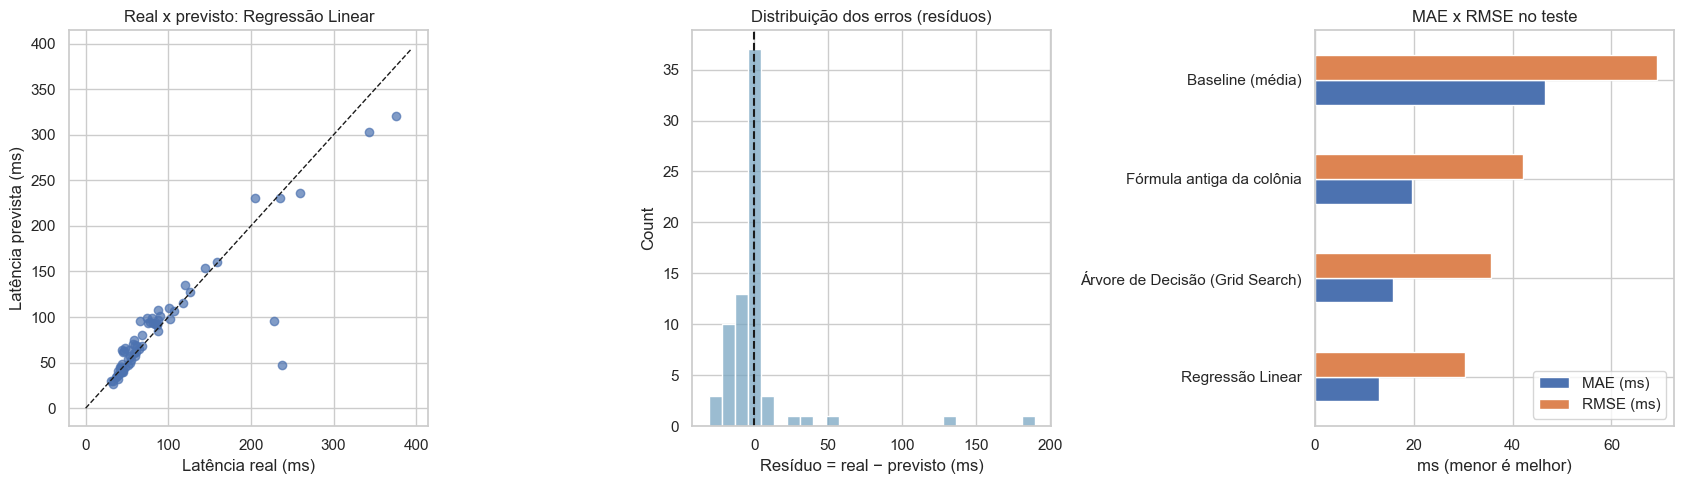

[gráfico salvo em graficos_ou_imagens\07_painel_performance_modelo.png]


In [24]:
# ==== 6.8 Painel gráfico de performance ====
y_prev_teste = modelo_final.predict(X_teste)
residuos = y_teste - y_prev_teste

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
# (a) Real x previsto
axes[0].scatter(y_teste, y_prev_teste, alpha=0.7, color="#4c72b0")
lim = [0, max(y_teste.max(), y_prev_teste.max()) * 1.05]
axes[0].plot(lim, lim, "k--", linewidth=1)
axes[0].set_xlabel("Latência real (ms)")
axes[0].set_ylabel("Latência prevista (ms)")
axes[0].set_title(f"Real x previsto: {NOME_MELHOR}")
# (b) Distribuição dos resíduos
sns.histplot(residuos, bins=25, ax=axes[1], color="#7aa6c2")
axes[1].axvline(0, color="k", linestyle="--")
axes[1].set_xlabel("Resíduo = real − previsto (ms)")
axes[1].set_title("Distribuição dos erros (resíduos)")
# (c) MAE e RMSE de cada modelo
tabela_teste[["MAE (ms)", "RMSE (ms)"]].plot.barh(ax=axes[2], color=["#4c72b0", "#dd8452"])
axes[2].set_xlabel("ms (menor é melhor)")
axes[2].set_title("MAE x RMSE no teste")
salvar_grafico("07_painel_performance_modelo.png")

### 6.9 Comparação de modelos com AIC e BIC

AIC e BIC medem o equilíbrio entre **qualidade do ajuste** e **complexidade** (número de parâmetros). **Menor é melhor.** O BIC penaliza mais os modelos complexos. Comparamos duas regressões lineares:

- **Modelo A (simples):** só a carga de tráfego e o módulo.
- **Modelo B (completo):** todas as variáveis, ou seja, também sinal, temperatura e tempestade.

Fórmulas para regressão com erros normais: $AIC = n\ln(SQR/n) + 2k$ e $BIC = n\ln(SQR/n) + k\ln(n)$, em que SQR é a soma dos quadrados dos resíduos e k é o número de parâmetros.

In [25]:
# ==== 6.9 AIC e BIC ====
def aic_bic(modelo, X_, y_):
    n = len(y_)
    k = X_.shape[1] + 1                       # coeficientes + intercepto
    sqr = float(((y_ - modelo.predict(X_)) ** 2).sum())
    return n * math.log(sqr / n) + 2 * k, n * math.log(sqr / n) + k * math.log(n), k


colunas_A = ["carga_trafego_mbps"] + [c for c in X_treino.columns if c.startswith("mod_")]
modelo_A = LinearRegression().fit(X_treino[colunas_A], y_treino)
aic_A, bic_A, k_A = aic_bic(modelo_A, X_treino[colunas_A], y_treino)
aic_B, bic_B, k_B = aic_bic(linear, X_treino, y_treino)

print(f"{'Modelo':<28}{'parâmetros':>11}{'AIC':>10}{'BIC':>10}")
print(f"{'A (carga + módulo)':<28}{k_A:>11}{aic_A:>10.1f}{bic_A:>10.1f}")
print(f"{'B (todas as variáveis)':<28}{k_B:>11}{aic_B:>10.1f}{bic_B:>10.1f}")
melhor = "B" if aic_B < aic_A and bic_B < bic_A else "A"
print(f"\nAIC e BIC indicam o modelo {melhor}: as variáveis extras (sinal, tempestade, temperatura) "
      f"{'compensam' if melhor == 'B' else 'não compensam'} o aumento de complexidade.")

Modelo                       parâmetros       AIC       BIC
A (carga + módulo)                   14    1576.1    1623.1
B (todas as variáveis)               17    1490.2    1547.3

AIC e BIC indicam o modelo B: as variáveis extras (sinal, tempestade, temperatura) compensam o aumento de complexidade.


## 7. Priorização de alertas com heap (fila de prioridade)

**Problema:** em um ciclo ruim surgem dezenas de alertas ao mesmo tempo. A equipe precisa atender **primeiro o mais urgente**, como na triagem de um pronto-socorro.

**Como cada alerta é representado:** um dicionário com `prioridade`, `ciclo`, `modulo`, `codigo_sensor`, `mensagem`, `erro_relativo` e `qualidade_sinal_pct`.

**Critério de prioridade (pontuação de 0 a 100):**

| Critério | Pontos | Por quê |
|---|---|---|
| Status operacional | alerta = 30 · manutenção = 15 · ativo = 0 | Situação já sinalizada pelo próprio módulo |
| Módulo essencial | (nível de prioridade ÷ 5) × 30 | Suporte médico, comando e comunicação são vitais |
| Erro relativo da latência | min(erro ÷ 50%, 1) × 25 | Quanto mais a previsão falhou, maior o risco |
| Qualidade do sinal | (100 − qualidade) ÷ 100 × 15 | Sinal fraco indica risco de perder o enlace |
| **Desempate** | ciclo mais antigo primeiro | Considera o tempo de espera desde o registro |

**Como o heap funciona (max-heap):** é uma árvore binária guardada dentro de uma lista. Cada "pai" tem prioridade **maior ou igual** à dos seus "filhos", então **o mais urgente está sempre na posição 0**. Para o elemento na posição `i`: pai = `(i−1)//2`, filho esquerdo = `2i+1`, filho direito = `2i+2`.
- **Inserir:** coloca o alerta no fim da lista e o faz **subir** (*heapify-up*) enquanto for mais urgente que o pai.
- **Remover o mais urgente:** retira a raiz, coloca o último elemento no topo e o faz **descer** (*heapify-down*) até a posição correta.

In [26]:
# ==== 7.1 Pontuação de prioridade ====
PONTOS_STATUS = {"alerta": 30, "manutenção": 15, "ativo": 0}


def calcular_prioridade(registro):
    """Pontuação de 0 a 100: quanto maior, mais urgente."""
    pontos_status = PONTOS_STATUS.get(registro["status_operacional"], 0)
    pontos_essencial = registro["nivel_prioridade"] / 5 * 30
    pontos_latencia = min(registro["erro_relativo"] / 0.50, 1.0) * 25
    pontos_sinal = (100 - registro["qualidade_sinal_pct"]) / 100 * 15
    return round(pontos_status + pontos_essencial + pontos_latencia + pontos_sinal, 2)


def criar_alerta(registro):
    """Converte uma linha do DataFrame no dicionário que representa um alerta."""
    return {"prioridade": calcular_prioridade(registro),
            "ciclo": int(registro["ciclo"]),
            "modulo": registro["modulo"],
            "codigo_sensor": registro["codigo_sensor"],
            "status": registro["status_operacional"],
            "mensagem": registro["mensagem_alerta"],
            "erro_relativo": round(float(registro["erro_relativo"]), 3),
            "qualidade_sinal_pct": float(registro["qualidade_sinal_pct"])}


# ==== 7.2 Max-heap implementado do zero ====
class FilaPrioridadeAlertas:
    """Max-heap: o alerta de maior prioridade fica sempre na posição 0 da lista."""

    def __init__(self):
        self.heap = []
        self.trocas = 0                      # contador didático de trocas realizadas

    @staticmethod
    def _chave(alerta):
        # Maior prioridade primeiro; em caso de empate, o ciclo mais antigo (−ciclo maior) vence
        return (alerta["prioridade"], -alerta["ciclo"])

    def _mais_urgente(self, i, j):
        return self._chave(self.heap[i]) > self._chave(self.heap[j])

    def _trocar(self, i, j):
        self.heap[i], self.heap[j] = self.heap[j], self.heap[i]
        self.trocas += 1

    def _heapify_up(self, i):
        """Sobe o elemento i enquanto ele for mais urgente que o pai."""
        while i > 0:
            pai = (i - 1) // 2
            if not self._mais_urgente(i, pai):
                break
            self._trocar(i, pai)
            i = pai

    def _heapify_down(self, i):
        """Desce o elemento i trocando-o com o filho mais urgente, até restaurar a propriedade do heap."""
        n = len(self.heap)
        while True:
            esq, dir_ = 2 * i + 1, 2 * i + 2
            maior = i
            if esq < n and self._mais_urgente(esq, maior):
                maior = esq
            if dir_ < n and self._mais_urgente(dir_, maior):
                maior = dir_
            if maior == i:
                break
            self._trocar(i, maior)
            i = maior

    def inserir(self, alerta):                       # O(log n)
        self.heap.append(alerta)
        self._heapify_up(len(self.heap) - 1)

    def remover_mais_urgente(self):                  # O(log n)
        if not self.heap:
            return None
        self._trocar(0, len(self.heap) - 1)
        alerta = self.heap.pop()
        if self.heap:
            self._heapify_down(0)
        return alerta

    def espiar(self):                                # O(1): consulta sem remover
        return self.heap[0] if self.heap else None

    def __len__(self):
        return len(self.heap)

In [27]:
# ==== 7.3 Demonstração passo a passo com 6 alertas ====
exemplos = df[df["status_operacional"] != "ativo"].sample(6, random_state=7)
demo = FilaPrioridadeAlertas()
for _, linha in exemplos.iterrows():
    alerta = criar_alerta(linha)
    demo.inserir(alerta)
    print(f"Inseriu {alerta['modulo']:<24} (prioridade {alerta['prioridade']:5.1f}) -> "
          f"heap = {[a['prioridade'] for a in demo.heap]}")
print(f"\nRaiz do heap (mais urgente): {demo.espiar()['modulo']} com prioridade {demo.espiar()['prioridade']}")
print("Removendo em ordem de urgência:", [demo.remover_mais_urgente()["prioridade"] for _ in range(len(demo))])

Inseriu Suporte Médico           (prioridade  88.9) -> heap = [88.86]
Inseriu Comunicação Orbital      (prioridade  81.2) -> heap = [88.86, 81.19]
Inseriu Comunicação Orbital      (prioridade  81.2) -> heap = [88.86, 81.19, 81.24]
Inseriu Laboratório Biológico    (prioridade  69.1) -> heap = [88.86, 81.19, 81.24, 69.06]
Inseriu Laboratório Biológico    (prioridade  69.9) -> heap = [88.86, 81.19, 81.24, 69.06, 69.93]
Inseriu Comunicação Orbital      (prioridade  85.6) -> heap = [88.86, 81.19, 85.6, 69.06, 69.93, 81.24]

Raiz do heap (mais urgente): Suporte Médico com prioridade 88.86
Removendo em ordem de urgência: [88.86, 85.6, 81.24, 81.19, 69.93, 69.06]


Repare que a **lista interna não fica totalmente ordenada**. Só é garantido que cada pai é maior que seus filhos. Mesmo assim, as remoções saem **sempre em ordem decrescente de prioridade**. É isso que torna o heap eficiente: ele faz apenas o trabalho necessário para entregar o próximo mais urgente.

In [28]:
# ==== 7.4 Fila com TODOS os alertas da colônia ====
def construir_fila_alertas(dados):
    """Insere no heap todos os registros com status diferente de 'ativo'."""
    fila = FilaPrioridadeAlertas()
    for _, linha in dados[dados["status_operacional"] != "ativo"].iterrows():
        fila.inserir(criar_alerta(linha))
    return fila


def mostrar_top_alertas(fila, n=10):
    """Remove os n alertas mais urgentes de uma CÓPIA da fila (a fila original continua intacta)."""
    copia = FilaPrioridadeAlertas()
    copia.heap = list(fila.heap)
    linhas = [copia.remover_mais_urgente() for _ in range(min(n, len(copia)))]
    return pd.DataFrame(linhas)[["prioridade", "ciclo", "modulo", "codigo_sensor", "status",
                                 "mensagem", "erro_relativo", "qualidade_sinal_pct"]]


fila_alertas = construir_fila_alertas(df)
print(f"Alertas na fila: {len(fila_alertas)} | Trocas feitas pelo heap na construção: {fila_alertas.trocas}")
print(f"Alerta mais urgente agora: {fila_alertas.espiar()['modulo']} (ciclo {fila_alertas.espiar()['ciclo']}) "
      f"- {fila_alertas.espiar()['mensagem']}\n")
top_alertas = mostrar_top_alertas(fila_alertas, 10)
top_alertas

Alertas na fila: 77 | Trocas feitas pelo heap na construção: 94
Alerta mais urgente agora: Energia Solar (ciclo 14) - Perda parcial de sinal durante tempestade de poeira



,prioridade,ciclo,modulo,codigo_sensor,status,mensagem,erro_relativo,qualidade_sinal_pct
0,89.77,14,Energia Solar,0x7105,alerta,Perda parcial de sinal durante tempestade de p...,0.549,68.2
1,89.66,12,Controle Ambiental,0x82B3,alerta,Perda parcial de sinal durante tempestade de p...,0.628,68.9
2,89.56,12,Energia Solar,0x7105,alerta,Perda parcial de sinal durante tempestade de p...,0.536,69.6
3,89.41,12,Suporte Médico,0x51C2,alerta,Perda parcial de sinal durante tempestade de p...,0.587,70.6
4,89.22,16,Energia Solar,0x7105,alerta,Perda parcial de sinal durante tempestade de p...,0.526,71.9
5,89.17,15,Comando Principal,0x81A0,alerta,Perda parcial de sinal durante tempestade de p...,0.632,72.2
6,89.09,12,Comando Principal,0x81A0,alerta,Perda parcial de sinal durante tempestade de p...,0.655,72.7
7,89.08,16,Suporte Médico,0x51C2,alerta,Perda parcial de sinal durante tempestade de p...,0.598,72.8
8,89.06,15,Energia Solar,0x7105,alerta,Perda parcial de sinal durante tempestade de p...,0.524,72.9
9,88.87,14,Comando Principal,0x81A0,alerta,Perda parcial de sinal durante tempestade de p...,0.618,74.2


In [29]:
# ==== 7.5 Conferência: o nosso heap concorda com uma ordenação completa e com o heapq do Python? ====
copia = FilaPrioridadeAlertas()
copia.heap = list(fila_alertas.heap)
ordem_heap = [FilaPrioridadeAlertas._chave(copia.remover_mais_urgente()) for _ in range(len(fila_alertas))]
ordem_sorted = sorted((FilaPrioridadeAlertas._chave(a) for a in fila_alertas.heap), reverse=True)

# heapq é um MIN-heap; usamos a chave negativa para simular um max-heap
heap_python = [(-p, c) for p, c in ordem_sorted]
heapq.heapify(heap_python)
ordem_heapq = [(-p, c) for p, c in (heapq.heappop(heap_python) for _ in range(len(ordem_sorted)))]

print("Ordem igual à ordenação completa (sorted)?", ordem_heap == ordem_sorted)
print("Ordem igual ao heapq da biblioteca padrão? ", ordem_heap == ordem_heapq)

Ordem igual à ordenação completa (sorted)? True
Ordem igual ao heapq da biblioteca padrão?  True


In [30]:
# ==== 7.6 Vantagem do heap sobre uma lista simples ====
random.seed(SEED)
N, K_EXTRACOES = 10_000, 1_000
alertas_sinteticos = [{"prioridade": round(random.uniform(0, 100), 2), "ciclo": random.randint(1, 30)}
                      for _ in range(N)]

# Estratégia 1: lista simples -> procurar o máximo percorre a lista inteira a cada extração (O(n))
lista = list(alertas_sinteticos)
inicio = time.perf_counter()
for _ in range(K_EXTRACOES):
    i_max = max(range(len(lista)), key=lambda i: FilaPrioridadeAlertas._chave(lista[i]))
    lista.pop(i_max)
t_lista = time.perf_counter() - inicio

# Estratégia 2: heap -> o máximo já está na raiz; remover custa O(log n)
fila_teste = FilaPrioridadeAlertas()
for a in alertas_sinteticos:
    fila_teste.inserir(a)
inicio = time.perf_counter()
for _ in range(K_EXTRACOES):
    fila_teste.remover_mais_urgente()
t_heap = time.perf_counter() - inicio

print(f"Extrair os {K_EXTRACOES} alertas mais urgentes de {N}:")
print(f"  Lista simples: {t_lista:.3f} s  (cada extração examina ~{N} elementos)")
print(f"  Heap:          {t_heap:.3f} s  (cada extração desce no máximo ~log2({N}) ≈ {math.log2(N):.0f} níveis)")
print(f"  O heap foi ~{t_lista / t_heap:.0f}× mais rápido.")

Extrair os 1000 alertas mais urgentes de 10000:
  Lista simples: 1.416 s  (cada extração examina ~10000 elementos)
  Heap:          0.009 s  (cada extração desce no máximo ~log2(10000) ≈ 13 níveis)
  O heap foi ~164× mais rápido.


## 8. Busca por prefixo com trie (árvore de prefixos)

**Problema:** o operador digita só o começo de um nome ou código ("com", "0x3", "temp") e precisa ver na hora **todos os registros compatíveis**, como no autocompletar do celular.

**Como a trie funciona:** cada **nó** representa uma letra. Palavras com o mesmo começo **compartilham o mesmo caminho**:

```
(raiz)
  └─ c ─ o ─┬─ m ─┬─ u ─ n ─ i ... "comunicacao central", "comunicacao orbital"
            │     └─ a ─ n ─ d ─ o ... "comando principal"
            └─ n ─ t ─ r ─ o ─ l ─ e ... "controle ambiental"
```

Para buscar o prefixo "com", basta **descer 3 nós** (c → o → m) e recolher tudo o que está abaixo. **O custo depende do tamanho do prefixo, não da quantidade de registros.** Uma lista comum precisaria comparar o prefixo com **todos** os itens.

Usamos três tries: **nomes de módulos**, **códigos de sensores** e **palavras-chave das mensagens de alerta**. Os textos são normalizados (minúsculas, sem acentos), então "com" encontra "Comunicação".

In [31]:
# ==== 8.1 Implementação da trie ====
def normalizar(texto):
    """Minúsculas e sem acentos: 'Comunicação' -> 'comunicacao'."""
    sem_acento = unicodedata.normalize("NFD", str(texto)).encode("ascii", "ignore").decode("ascii")
    return sem_acento.lower().strip()


class NoTrie:
    def __init__(self):
        self.filhos = {}            # letra -> próximo nó
        self.fim_de_termo = False   # True se algum termo termina aqui
        self.termo_original = None  # termo com acentos e maiúsculas, para exibir
        self.referencias = []       # índices dos registros do DataFrame ligados ao termo


class Trie:
    def __init__(self):
        self.raiz = NoTrie()
        self.total_termos = 0

    def inserir(self, termo, referencia=None):
        """Percorre (criando quando preciso) um nó por letra do termo."""
        no = self.raiz
        for letra in normalizar(termo):
            no = no.filhos.setdefault(letra, NoTrie())
        if not no.fim_de_termo:
            no.fim_de_termo = True
            no.termo_original = termo
            self.total_termos += 1
        if referencia is not None:
            no.referencias.append(referencia)

    def _descer(self, prefixo):
        """Desce pela trie seguindo as letras do prefixo. Retorna o nó final (ou None)."""
        no = self.raiz
        for letra in normalizar(prefixo):
            if letra not in no.filhos:
                return None
            no = no.filhos[letra]
        return no

    def buscar_prefixo(self, prefixo):
        """Retorna [(termo, referências)] de todos os termos que começam com o prefixo."""
        no = self._descer(prefixo)
        if no is None:
            return []
        encontrados, pilha = [], [no]
        while pilha:                               # busca em profundidade (DFS) a partir do nó do prefixo
            atual = pilha.pop()
            if atual.fim_de_termo:
                encontrados.append((atual.termo_original, atual.referencias))
            pilha.extend(atual.filhos.values())
        return sorted(encontrados, key=lambda par: normalizar(par[0]))

    def contem(self, termo):
        no = self._descer(termo)
        return no is not None and no.fim_de_termo

In [32]:
# ==== 8.2 Construção das tries a partir dos dados ====
def construir_tries(dados):
    """Cria as tries de módulos, sensores e palavras-chave de alerta (guardando os índices dos registros)."""
    t_modulos, t_sensores, t_palavras = Trie(), Trie(), Trie()
    for idx, linha in dados.iterrows():
        t_modulos.inserir(linha["modulo"], idx)
        t_sensores.inserir(linha["codigo_sensor"], idx)
        if linha["mensagem_alerta"] != "Sem alerta":
            for palavra in linha["mensagem_alerta"].split():
                if len(palavra) >= 4:              # ignora palavras curtas como "de", "do", "no"
                    t_palavras.inserir(palavra, idx)
    return t_modulos, t_sensores, t_palavras


trie_modulos, trie_sensores, trie_palavras = construir_tries(df)
print(f"Trie de módulos: {trie_modulos.total_termos} termos | sensores: {trie_sensores.total_termos} | "
      f"palavras de alerta: {trie_palavras.total_termos}")


def exibir_busca(trie, prefixo, rotulo):
    resultados = trie.buscar_prefixo(prefixo)
    print(f"\n[{rotulo}] prefixo '{prefixo}' -> {len(resultados)} resultado(s):")
    for termo, refs in resultados:
        print(f"   • {termo:<26} ({len(refs)} registros)")
    if not resultados:
        print("   (nenhum termo encontrado)")


exibir_busca(trie_modulos, "com", "Módulos")
exibir_busca(trie_modulos, "co", "Módulos")
exibir_busca(trie_modulos, "lab", "Módulos")
exibir_busca(trie_sensores, "0x3", "Sensores de comunicação")
exibir_busca(trie_sensores, "0x8", "Sensores de comando/controle")
exibir_busca(trie_palavras, "temp", "Palavras de alerta")
exibir_busca(trie_palavras, "lat", "Palavras de alerta")
exibir_busca(trie_modulos, "xyz", "Módulos")

Trie de módulos: 12 termos | sensores: 12 | palavras de alerta: 18

[Módulos] prefixo 'com' -> 3 resultado(s):
   • Comando Principal          (28 registros)
   • Comunicação Central        (30 registros)
   • Comunicação Orbital        (30 registros)

[Módulos] prefixo 'co' -> 4 resultado(s):
   • Comando Principal          (28 registros)
   • Comunicação Central        (30 registros)
   • Comunicação Orbital        (30 registros)
   • Controle Ambiental         (29 registros)

[Módulos] prefixo 'lab' -> 2 resultado(s):
   • Laboratório Biológico      (30 registros)
   • Laboratório Geológico      (30 registros)

[Sensores de comunicação] prefixo '0x3' -> 2 resultado(s):
   • 0x310A                     (30 registros)
   • 0x32F1                     (30 registros)

[Sensores de comando/controle] prefixo '0x8' -> 2 resultado(s):
   • 0x81A0                     (28 registros)
   • 0x82B3                     (29 registros)

[Palavras de alerta] prefixo 'temp' -> 1 resultado(s):
   • tempe

In [33]:
# ==== 8.3 Da busca ao registro: consultar os registros de quem combina com o prefixo ====
def buscar_registros(prefixo, trie=None, dados=None, ultimos=None):
    """Usa a trie para achar os índices e devolve as linhas correspondentes do DataFrame."""
    trie = trie if trie is not None else trie_modulos
    dados = dados if dados is not None else df
    indices = sorted({i for _, refs in trie.buscar_prefixo(prefixo) for i in refs})
    resultado = dados.loc[indices, ["ciclo", "modulo", "codigo_sensor", "latencia_prevista_ms",
                                    "latencia_observada_ms", "erro_relativo", "status_operacional",
                                    "mensagem_alerta"]]
    return resultado.tail(ultimos) if ultimos else resultado


print("Registros de alerta que contêm uma palavra iniciada por 'pico' (picos de latência):")
buscar_registros("pico", trie=trie_palavras)

Registros de alerta que contêm uma palavra iniciada por 'pico' (picos de latência):


,ciclo,modulo,codigo_sensor,latencia_prevista_ms,latencia_observada_ms,erro_relativo,status_operacional,mensagem_alerta
10,1,Laboratório Geológico,0x4107,82.8,257.5,0.678447,alerta,Pico de latência detectado no enlace
31,3,Habitação Alfa,0x110A,51.3,192.3,0.733229,alerta,Pico de latência detectado no enlace
63,6,Comunicação Central,0x310A,42.4,237.6,0.821549,alerta,Pico de latência detectado no enlace
93,8,Laboratório Geológico,0x4107,85.1,227.6,0.626098,alerta,Pico de latência detectado no enlace
113,10,Habitação Alfa,0x110A,49.9,248.4,0.799114,alerta,Pico de latência detectado no enlace
116,10,Laboratório Geológico,0x4107,81.3,201.7,0.596926,alerta,Pico de latência detectado no enlace
176,16,Agricultura Hidropônica,0x2103,71.3,247.7,0.712152,alerta,Pico de latência detectado no enlace
188,17,Agricultura Hidropônica,0x2103,69.1,210.0,0.670952,alerta,Pico de latência detectado no enlace
198,18,Agricultura Hidropônica,0x2103,71.5,267.4,0.732610,alerta,Pico de latência detectado no enlace
267,23,Laboratório Biológico,0x4208,79.9,283.9,0.718563,alerta,Pico de latência detectado no enlace


In [34]:
# ==== 8.4 Vantagem da trie sobre a busca linear ====
random.seed(SEED)
codigos = list({f"0x{random.randint(0, 0xFFFFFF):06X}" for _ in range(50_000)})
trie_grande = Trie()
for c in codigos:
    trie_grande.inserir(c)

prefixo = "0x3A7"
inicio = time.perf_counter()
achados_linear = [c for c in codigos if normalizar(c).startswith(normalizar(prefixo))]
t_linear = time.perf_counter() - inicio
inicio = time.perf_counter()
achados_trie = [t for t, _ in trie_grande.buscar_prefixo(prefixo)]
t_trie = time.perf_counter() - inicio

print(f"{len(codigos)} códigos cadastrados | prefixo '{prefixo}' -> {len(achados_trie)} compatíveis")
print(f"Mesmos resultados? {sorted(achados_linear) == sorted(achados_trie)}")
print(f"Busca linear: {t_linear * 1000:.2f} ms (compara com todos os {len(codigos)} códigos)")
print(f"Trie:         {t_trie * 1000:.3f} ms (desce {len(prefixo)} nós e coleta só a sub-árvore)")
print(f"A trie foi ~{t_linear / t_trie:.0f}× mais rápida.")

49937 códigos cadastrados | prefixo '0x3A7' -> 13 compatíveis
Mesmos resultados? True
Busca linear: 26.99 ms (compara com todos os 49937 códigos)
Trie:         0.090 ms (desce 5 nós e coleta só a sub-árvore)
A trie foi ~300× mais rápida.


## 9. Dispositivos, bases numéricas e eletricidade aplicada à comunicação

### 9.1 Arquitetura do SCIC: entrada → processamento → saída

| Camada | Dispositivo (real ou simulado) | No protótipo |
|---|---|---|
| **Entrada** | Sensores de latência e qualidade de sinal nos rádios; medidores de tensão e corrente (com conversor analógico-digital, ADC); termômetros dos equipamentos; teclado do operador | Colunas do CSV e `input()` no menu |
| **Interface de comunicação** | Rede cabeada (Ethernet) entre módulos; Wi-Fi e Bluetooth para sensores IoT; USB para manutenção local; enlace de rádio com satélite para falar com a Terra | Conceitual (simulado pelo arquivo) |
| **Processamento** | Computador da central de comunicação | Python + Pandas + scikit-learn |
| **Saída** | Monitor/terminal, painel de LEDs de alerta, relatórios e gráficos, alarme sonoro | `print`, tabelas, gráficos salvos em PNG, relatório técnico |

### 9.2 Códigos de sensores em bases numéricas

Cada sensor tem um código **hexadecimal de 16 bits** no formato `0xTMSS`:
- **T** (4 bits): tipo do módulo (1 = habitação, 2 = agricultura, 3 = comunicação, 4 = laboratório, 5 = suporte médico, 6 = armazenamento, 7 = energia, 8 = comando/controle)
- **M** (4 bits): número do módulo dentro do tipo
- **SS** (8 bits): número do sensor

Usar hexadecimal é prático: **cada dígito hex corresponde a exatamente 4 bits**, então o código é fácil de ler para humanos e de processar para o hardware.

In [35]:
# ==== 9.2 Conversões manuais entre bases ====
DIGITOS = "0123456789ABCDEF"
TIPOS_SENSOR = {1: "habitação", 2: "agricultura", 3: "comunicação", 4: "laboratório",
                5: "suporte médico", 6: "armazenamento", 7: "energia", 8: "comando/controle"}


def decimal_para_base(numero, base):
    """Método das divisões sucessivas: os restos, lidos de baixo para cima, formam o número."""
    if numero == 0:
        return "0"
    resultado = ""
    while numero > 0:
        resultado = DIGITOS[numero % base] + resultado
        numero //= base
    return resultado


def base_para_decimal(texto, base):
    """Soma de cada dígito × base^posição (posição 0 = dígito mais à direita)."""
    texto = texto.upper().replace("0X", "")
    total = 0
    for posicao, digito in enumerate(reversed(texto)):
        total += DIGITOS.index(digito) * base ** posicao
    return total


def decodificar_sensor(codigo_hex, detalhar=True):
    """Converte o código para decimal e binário e separa os campos usando operações de bits."""
    valor = base_para_decimal(codigo_hex, 16)
    binario = decimal_para_base(valor, 2).zfill(16)
    tipo, modulo, sensor = (valor >> 12) & 0xF, (valor >> 8) & 0xF, valor & 0xFF
    if detalhar:
        hex_limpo = codigo_hex.upper().replace("0X", "")
        parcelas = " + ".join(f"{d}×16^{len(hex_limpo) - 1 - i}" for i, d in enumerate(hex_limpo))
        print(f"Código {codigo_hex}")
        print(f"  Hexadecimal -> decimal: {parcelas} = {valor}")
        print(f"  Decimal -> binário (divisões sucessivas por 2): {' '.join(binario[i:i + 4] for i in range(0, 16, 4))}")
        print(f"  Conferência com as funções do Python: int('{codigo_hex}', 16) = {int(codigo_hex, 16)} | "
              f"bin = {bin(valor)} | hex = {hex(valor)}")
        print(f"  Campos: tipo = {tipo} ({TIPOS_SENSOR.get(tipo, '?')}), módulo nº {modulo}, sensor nº {sensor} (0x{sensor:02X})")
    return {"codigo_hex": codigo_hex, "decimal": valor, "binario": binario,
            "tipo": TIPOS_SENSOR.get(tipo, "?"), "modulo_n": modulo, "sensor_n": sensor}


decodificar_sensor("0x32F1")
print()
tabela_codigos = pd.DataFrame([decodificar_sensor(c, detalhar=False) | {"modulo": m}
                               for m, c in df.groupby("modulo")["codigo_sensor"].first().items()])
tabela_codigos

Código 0x32F1
  Hexadecimal -> decimal: 3×16^3 + 2×16^2 + F×16^1 + 1×16^0 = 13041
  Decimal -> binário (divisões sucessivas por 2): 0011 0010 1111 0001
  Conferência com as funções do Python: int('0x32F1', 16) = 13041 | bin = 0b11001011110001 | hex = 0x32f1
  Campos: tipo = 3 (comunicação), módulo nº 2, sensor nº 241 (0xF1)



,codigo_hex,decimal,binario,tipo,modulo_n,sensor_n,modulo
0,0x2103,8451,0010000100000011,agricultura,1,3,Agricultura Hidropônica
1,0x61D4,25044,0110000111010100,armazenamento,1,212,Armazenamento de Dados
2,0x81A0,33184,1000000110100000,comando/controle,1,160,Comando Principal
3,0x310A,12554,0011000100001010,comunicação,1,10,Comunicação Central
4,0x32F1,13041,0011001011110001,comunicação,2,241,Comunicação Orbital
5,0x82B3,33459,1000001010110011,comando/controle,2,179,Controle Ambiental
6,0x7105,28933,0111000100000101,energia,1,5,Energia Solar
7,0x110A,4362,0001000100001010,habitação,1,10,Habitação Alfa
8,0x120B,4619,0001001000001011,habitação,2,11,Habitação Beta
9,0x4208,16904,0100001000001000,laboratório,2,8,Laboratório Biológico


### 9.3 Representação de uma leitura analógica (ADC)

O sensor de tensão do barramento de 48 V do enlace orbital usa um **divisor de tensão 10:1** e um **ADC de 10 bits** com referência de 5 V. O ADC entrega um número inteiro de 0 a 1023, e o software converte esse número de volta em volts. Como só existem 1024 níveis, há um **erro de quantização**: mais um exemplo de erro numérico causado pela representação.

In [36]:
# ==== 9.3 Conversão analógico-digital ====
V_REF, BITS, DIVISOR = 5.0, 10, 10
NIVEIS = 2 ** BITS - 1                                   # 1023
tensao_real = float(orbital["tensao_v"].iloc[0])        # tensão medida no 1º ciclo do enlace orbital
leitura_adc = round(tensao_real / DIVISOR / V_REF * NIVEIS)
tensao_reconstruida = leitura_adc / NIVEIS * V_REF * DIVISOR
resolucao = V_REF / NIVEIS * DIVISOR

print(f"Tensão real no barramento: {tensao_real:.3f} V")
print(f"Leitura do ADC: {leitura_adc} (decimal) = {decimal_para_base(leitura_adc, 2).zfill(BITS)} (binário) "
      f"= 0x{decimal_para_base(leitura_adc, 16)} (hex)")
print(f"Tensão reconstruída pelo software: {tensao_reconstruida:.3f} V")
print(f"Erro de quantização: {erro_absoluto(tensao_reconstruida, tensao_real) * 1000:.1f} mV "
      f"(resolução do sistema = {resolucao * 1000:.1f} mV por nível)")

Tensão real no barramento: 48.390 V
Leitura do ADC: 990 (decimal) = 1111011110 (binário) = 0x3DE (hex)
Tensão reconstruída pelo software: 48.387 V
Erro de quantização: 2.9 mV (resolução do sistema = 48.9 mV por nível)


### 9.4 Eletricidade básica aplicada à comunicação

| Grandeza | Fórmula | Uso no SCIC |
|---|---|---|
| Potência elétrica | P = V × I | Consumo do equipamento de rádio |
| Lei de Ohm | V = R × I → R = V ÷ I | Resistência equivalente da carga e cálculo de resistores |
| Energia | E = P × t | Consumo por sol (sustentabilidade) |
| Potência de transmissão | P_tx = η × P_elétrica; em dBm: 10·log10(P em mW) | Quanto da energia vira sinal de rádio |

In [37]:
# ==== 9.4 Cálculos elétricos ====
v_med, i_med = orbital["tensao_v"].mean(), orbital["corrente_a"].mean()
p_eletrica = v_med * i_med                         # P = V × I
r_equivalente = v_med / i_med                      # Lei de Ohm: R = V / I
energia_sol_kwh = p_eletrica * HORAS_POR_SOL / 1000
EFICIENCIA_AMPLIFICADOR = 0.35                     # hipótese: 35% da potência elétrica vira sinal de rádio
p_tx_w = EFICIENCIA_AMPLIFICADOR * p_eletrica
p_tx_dbm = 10 * math.log10(p_tx_w * 1000)

print("Transmissor da Comunicação Orbital (médias dos 30 ciclos):")
print(f"  Tensão = {v_med:.2f} V | Corrente = {i_med:.2f} A")
print(f"  Potência elétrica P = V × I = {v_med:.2f} × {i_med:.2f} = {p_eletrica:.1f} W")
print(f"  Resistência equivalente R = V / I = {r_equivalente:.2f} Ω")
print(f"  Energia em 1 sol a plena carga E = P × t = {p_eletrica:.1f} W × {HORAS_POR_SOL} h = {energia_sol_kwh:.2f} kWh")
print(f"  Potência de transmissão (η = 35%) = {p_tx_w:.1f} W = {p_tx_dbm:.1f} dBm")

v_tempestade = orbital.loc[orbital["tempestade_poeira"] == 1, "tensao_v"].mean()
v_normal = orbital.loc[orbital["tempestade_poeira"] == 0, "tensao_v"].mean()
print(f"\nDurante a tempestade, a tensão média caiu de {v_normal:.2f} V para {v_tempestade:.2f} V "
      f"({v_tempestade / v_normal - 1:.1%}), porque os painéis solares geraram menos energia.")

# LED vermelho do painel de alertas (dispositivo de SAÍDA) alimentado por 5 V
V_FONTE, V_LED, I_LED = 5.0, 2.0, 0.020
R_LED = (V_FONTE - V_LED) / I_LED
print(f"\nLED de alerta do painel: R = (V_fonte − V_LED) / I = ({V_FONTE} − {V_LED}) / {I_LED} = {R_LED:.0f} Ω")
print(f"  Potência dissipada no resistor: P = I² × R = {I_LED ** 2 * R_LED:.2f} W -> um resistor de 1/4 W é suficiente.")

Transmissor da Comunicação Orbital (médias dos 30 ciclos):
  Tensão = 47.51 V | Corrente = 5.40 A
  Potência elétrica P = V × I = 47.51 × 5.40 = 256.7 W
  Resistência equivalente R = V / I = 8.79 Ω
  Energia em 1 sol a plena carga E = P × t = 256.7 W × 24.65 h = 6.33 kWh
  Potência de transmissão (η = 35%) = 89.9 W = 49.5 dBm

Durante a tempestade, a tensão média caiu de 48.08 V para 44.64 V (-7.2%), porque os painéis solares geraram menos energia.

LED de alerta do painel: R = (V_fonte − V_LED) / I = (5.0 − 2.0) / 0.02 = 150 Ω
  Potência dissipada no resistor: P = I² × R = 0.06 W -> um resistor de 1/4 W é suficiente.


## 10. Sistema integrado e menu de navegação

Aqui todas as partes se juntam. A função `analisar_alertas_comunicacao` implementa o **exemplo de funcionalidade do enunciado**:
1. carrega a base;
2. identifica módulos com **latência acima do previsto**;
3. calcula o **erro** entre a latência estimada e a real;
4. **prioriza** os alertas com o heap;
5. permite **buscar por prefixo** com a trie.

Em seguida há um **menu de navegação**. Para a demonstração no notebook, o menu roda com **entradas pré-programadas**. Para usar de forma interativa, mude `MODO_INTERATIVO = True`.

In [38]:
# ==== 10.1 Funcionalidade integrada: "Analisar alertas de comunicação" ====
def preparar_base(caminho=ARQUIVO_DADOS):
    """Pipeline completo: carregar -> limpar -> indicadores -> erros."""
    return adicionar_erros(adicionar_indicadores(limpar_dados(carregar_dados(caminho))))


def analisar_alertas_comunicacao(dados, ciclo=None, n_top=5, prefixo=None):
    """Analisa as latências acima do previsto, prioriza com heap e (opcionalmente) filtra com trie."""
    base = dados if ciclo is None else dados[dados["ciclo"] == ciclo]
    acima = base[(base["latencia_observada_ms"] > base["latencia_prevista_ms"])
                 & (base["erro_relativo"] > LIMITE_ERRO_ACEITAVEL)]
    escopo = f"ciclo {ciclo}" if ciclo is not None else "todos os ciclos"
    print(f"[{escopo}] {len(acima)} de {len(base)} registros com latência acima do previsto (erro > 10%).")
    print(f"  Erro absoluto médio: {acima['erro_absoluto_ms'].mean():.1f} ms | "
          f"erro relativo médio: {acima['erro_relativo'].mean():.1%}")

    fila = FilaPrioridadeAlertas()
    for _, linha in acima.iterrows():
        fila.inserir(criar_alerta(linha))
    print(f"\n  Top {n_top} alertas por prioridade (heap):")
    for pos in range(1, min(n_top, len(fila)) + 1):
        a = fila.remover_mais_urgente()
        print(f"   {pos}. [{a['prioridade']:5.1f}] ciclo {a['ciclo']:>2} | {a['modulo']:<24} | "
              f"erro {a['erro_relativo']:.0%} | {a['mensagem']}")

    if prefixo:
        trie_local = Trie()
        for idx, linha in acima.iterrows():
            trie_local.inserir(linha["modulo"], idx)
        achados = trie_local.buscar_prefixo(prefixo)
        print(f"\n  Busca por prefixo '{prefixo}' entre os módulos com problema (trie):")
        for termo, refs in achados:
            print(f"   • {termo}: {len(refs)} registro(s) acima do previsto")
        if not achados:
            print("   (nenhum módulo com problema começa com esse prefixo)")


analisar_alertas_comunicacao(df, ciclo=CICLOS_TEMPESTADE[2], n_top=5, prefixo="com")

[ciclo 14] 12 de 12 registros com latência acima do previsto (erro > 10%).
  Erro absoluto médio: 65.3 ms | erro relativo médio: 51.4%

  Top 5 alertas por prioridade (heap):
   1. [ 89.8] ciclo 14 | Energia Solar            | erro 55% | Perda parcial de sinal durante tempestade de poeira
   2. [ 88.9] ciclo 14 | Comando Principal        | erro 62% | Perda parcial de sinal durante tempestade de poeira
   3. [ 88.2] ciclo 14 | Suporte Médico           | erro 57% | Latência acima do limite previsto
   4. [ 87.7] ciclo 14 | Comunicação Central      | erro 55% | Latência acima do limite previsto
   5. [ 87.4] ciclo 14 | Controle Ambiental       | erro 54% | Latência acima do limite previsto

  Busca por prefixo 'com' entre os módulos com problema (trie):
   • Comando Principal: 1 registro(s) acima do previsto
   • Comunicação Central: 1 registro(s) acima do previsto
   • Comunicação Orbital: 1 registro(s) acima do previsto


In [39]:
# ==== 10.2 Menu de navegação do SCIC ====
OPCOES_MENU = """
================= SCIC · AURORA SIGER =================
 1 - Carregar (recarregar) dados da colônia
 2 - Consultar registros de um módulo
 3 - Ver painel de indicadores
 4 - Ver resumo dos erros numéricos
 5 - Executar previsão de latência
 6 - Avaliar desempenho do modelo
 7 - Analisar alertas de comunicação (heap)
 8 - Buscar por prefixo (trie)
 9 - Cadastrar novo alerta manual
10 - Decodificar código de sensor (bases numéricas)
11 - Exibir análise final
 0 - Sair
========================================================"""


def montar_entrada_previsao(modulo, carga, qualidade, temperatura, tempestade):
    """Cria uma linha com as mesmas colunas usadas no treino do modelo."""
    linha = pd.DataFrame(0, index=[0], columns=X.columns)
    linha[["carga_trafego_mbps", "qualidade_sinal_pct", "temperatura_equip_c", "tempestade_poeira"]] = \
        [carga, qualidade, temperatura, tempestade]
    linha[f"mod_{modulo}"] = 1
    return linha


def menu_scic(entradas=None):
    """Menu do sistema. Se 'entradas' for uma lista, as respostas vêm dela (demonstração automática)."""
    global df, fila_alertas, trie_modulos, trie_sensores, trie_palavras
    fila_entradas = iter(entradas) if entradas is not None else None

    def ler(mensagem):
        if fila_entradas is None:
            return input(mensagem).strip()
        valor = next(fila_entradas, "0")
        print(f"{mensagem}{valor}")
        return valor

    def ler_numero(mensagem, minimo, maximo):
        while True:
            texto = ler(mensagem).replace(",", ".")
            try:
                valor = float(texto)
                if minimo <= valor <= maximo:
                    return valor
                print(f"  ⚠ Digite um valor entre {minimo} e {maximo}.")
            except ValueError:
                print("  ⚠ Valor inválido: digite um número (ex.: 42.5).")

    def escolher_modulo():
        prefixo = ler("  Digite o nome ou o início do nome do módulo: ")
        achados = trie_modulos.buscar_prefixo(prefixo)
        if not achados:
            print("  ⚠ Nenhum módulo encontrado com esse prefixo.")
            return None
        if len(achados) > 1:
            print("  Vários módulos encontrados: " + " | ".join(t for t, _ in achados))
            print(f"  Usando o primeiro: {achados[0][0]}")
        return achados[0][0]

    while True:
        print(OPCOES_MENU)
        opcao = ler("Escolha uma opção: ")
        if opcao == "0":
            print("Encerrando o SCIC. Boa missão, Aurora Siger! 🚀")
            break
        elif opcao == "1":
            df = preparar_base()
            fila_alertas = construir_fila_alertas(df)
            trie_modulos, trie_sensores, trie_palavras = construir_tries(df)
            print(f"  Base recarregada. Heap com {len(fila_alertas)} alertas e tries atualizadas.")
        elif opcao == "2":
            modulo = escolher_modulo()
            if modulo:
                print(buscar_registros(modulo, ultimos=5).to_string(index=False))
        elif opcao == "3":
            print(indicadores[["latencia_media_ms", "disponibilidade_pct", "alertas", "potencia_media_w"]].to_string())
        elif opcao == "4":
            print(erros_modulo.to_string())
        elif opcao == "5":
            modulo = escolher_modulo()
            if modulo:
                carga = ler_numero("  Carga de tráfego (Mbps, 0 a 200): ", 0, 200)
                qualidade = ler_numero("  Qualidade do sinal (%, 0 a 100): ", 0, 100)
                temperatura = ler_numero("  Temperatura do equipamento (°C, -20 a 80): ", -20, 80)
                tempestade = int(ler_numero("  Há tempestade de poeira? (1 = sim, 0 = não): ", 0, 1))
                previsao = modelo_final.predict(montar_entrada_previsao(modulo, carga, qualidade, temperatura, tempestade))[0]
                mae = resultados_teste[NOME_MELHOR]["MAE (ms)"]
                print(f"  ➜ Latência prevista para {modulo}: {previsao:.1f} ms "
                      f"(erro médio esperado de ±{mae:.1f} ms, segundo o MAE do teste)")
        elif opcao == "6":
            print(tabela_teste.to_string())
            print(f"  Modelo em uso: {NOME_MELHOR}")
        elif opcao == "7":
            n = int(ler_numero("  Quantos alertas mostrar? (1 a 20): ", 1, 20))
            print(mostrar_top_alertas(fila_alertas, n).to_string(index=False))
        elif opcao == "8":
            alvo = ler("  Buscar em [m]ódulos, [s]ensores ou [p]alavras de alerta? ").lower()
            trie = {"m": trie_modulos, "s": trie_sensores, "p": trie_palavras}.get(alvo[:1], trie_modulos)
            prefixo = ler("  Prefixo: ")
            exibir_busca(trie, prefixo, "Resultado")
        elif opcao == "9":
            modulo = escolher_modulo()
            if modulo:
                ref = df[df["modulo"] == modulo].iloc[-1]
                mensagem = ler("  Descrição do alerta: ") or "Alerta manual do operador"
                novo = ref.copy()
                novo["status_operacional"], novo["mensagem_alerta"] = "alerta", mensagem
                novo["erro_relativo"] = ler_numero("  Erro relativo observado (0 a 1, ex.: 0.6): ", 0, 1)
                novo["qualidade_sinal_pct"] = ler_numero("  Qualidade do sinal (%): ", 0, 100)
                alerta = criar_alerta(novo)
                fila_alertas.inserir(alerta)
                posicao = 1 + sorted((FilaPrioridadeAlertas._chave(a) for a in fila_alertas.heap),
                                     reverse=True).index(FilaPrioridadeAlertas._chave(alerta))
                print(f"  Alerta cadastrado com prioridade {alerta['prioridade']} -> posição {posicao} "
                      f"de {len(fila_alertas)} na fila.")
                print(f"  Mais urgente agora: {fila_alertas.espiar()['modulo']} ({fila_alertas.espiar()['prioridade']})")
        elif opcao == "10":
            codigo = ler("  Código do sensor em hexadecimal (ex.: 0x32F1): ")
            try:
                decodificar_sensor(codigo)
            except ValueError:
                print("  ⚠ Código inválido. Use apenas 0-9 e A-F, por exemplo 0x310A.")
        elif opcao == "11":
            exibir_analise_final()
        else:
            print("  ⚠ Opção inválida. Digite um número de 0 a 11.")

## 11. Análise final dos resultados

A função abaixo junta os resultados de todas as seções em um **resumo de apoio à decisão**. Ela também é usada pela opção 11 do menu.

In [40]:
# ==== 11.1 Análise final gerada a partir dos dados ====
def exibir_analise_final():
    tab = pd.crosstab(df["tempestade_poeira"], df["classe_erro"], normalize="index")
    m = resultados_teste[NOME_MELHOR]
    f = resultados_teste["Fórmula antiga da colônia"]
    top = fila_alertas.espiar()
    pior_erro = erros_modulo.index[0]
    print("==================== ANÁLISE FINAL DO SCIC ====================")
    print(f"1. Dados: {len(df)} registros válidos de {df['modulo'].nunique()} módulos em {df['ciclo'].nunique()} ciclos.")
    print(f"2. Disponibilidade da rede: {(df['status_operacional'] == 'ativo').mean():.1%}. "
          f"Módulo com mais alertas: {indicadores.index[0]}.")
    print(f"3. Fórmula antiga: erro relativo crítico em {tab.loc[0, 'crítico']:.0%} dos ciclos normais e em "
          f"{tab.loc[1, 'crítico']:.0%} dos ciclos de tempestade. Ela NÃO considera tempestades.")
    print(f"   Maior erro relativo médio: {pior_erro} ({erros_modulo.iloc[0]['erro_rel_medio_pct']:.1f}%).")
    print(f"4. Modelo ({NOME_MELHOR}): MAE {m['MAE (ms)']:.1f} ms, RMSE {m['RMSE (ms)']:.1f} ms, R² {m['R²']:.3f}. "
          f"A fórmula antiga tinha MAE {f['MAE (ms)']:.1f} ms e R² {f['R²']:.3f}.")
    print(f"   RMSE/MAE = {m['RMSE/MAE']:.2f}: os picos aleatórios continuam imprevisíveis, então o monitoramento contínuo é obrigatório.")
    print(f"5. Heap: {len(fila_alertas)} alertas organizados. O mais urgente é {top['modulo']} "
          f"(ciclo {top['ciclo']}, prioridade {top['prioridade']}: {top['mensagem']}).")
    print(f"6. Trie: buscas por prefixo em módulos, {trie_sensores.total_termos} códigos de sensor e "
          f"{trie_palavras.total_termos} palavras-chave de alerta.")
    print(f"7. Energia: a tempestade reduziu a tensão do enlace orbital em {abs(v_tempestade / v_normal - 1):.1%}. "
          f"Consumo total da comunicação: {df['consumo_kwh'].sum():.1f} kWh em 30 sóis.")
    print("RECOMENDAÇÕES:")
    print("  • Substituir a fórmula antiga pelo modelo treinado, revalidando-o a cada novo lote de dados.")
    print("  • Em alerta de tempestade, adiar transmissões não essenciais para a Terra e priorizar comando e suporte médico.")
    print("  • Inspecionar primeiro os módulos no topo do heap; a decisão final é sempre da equipe humana.")
    print("================================================================")


exibir_analise_final()

==================== ANÁLISE FINAL DO SCIC ====================
1. Dados: 354 registros válidos de 12 módulos em 30 ciclos.
2. Disponibilidade da rede: 78.2%. Módulo com mais alertas: Laboratório Geológico.
3. Fórmula antiga: erro relativo crítico em 4% dos ciclos normais e em 100% dos ciclos de tempestade. Ela NÃO considera tempestades.
   Maior erro relativo médio: Agricultura Hidropônica (20.0%).
4. Modelo (Regressão Linear): MAE 12.9 ms, RMSE 30.4 ms, R² 0.807. A fórmula antiga tinha MAE 19.7 ms e R² 0.630.
   RMSE/MAE = 2.35: os picos aleatórios continuam imprevisíveis, então o monitoramento contínuo é obrigatório.
5. Heap: 77 alertas organizados. O mais urgente é Energia Solar (ciclo 14, prioridade 89.77: Perda parcial de sinal durante tempestade de poeira).
6. Trie: buscas por prefixo em módulos, 12 códigos de sensor e 18 palavras-chave de alerta.
7. Energia: a tempestade reduziu a tensão do enlace orbital em 7.2%. Consumo total da comunicação: 524.4 kWh em 30 sóis.
RECOMENDAÇÕE

In [41]:
# ==== 11.2 Demonstração do menu (entradas pré-programadas) ====
# Simula um operador usando o sistema: consulta, previsão, alertas, busca, cadastro e decodificação.
MODO_INTERATIVO = False      # mude para True para digitar as opções você mesmo

if MODO_INTERATIVO:
    menu_scic()
else:
    menu_scic(entradas=[
        "2", "comando",                                   # consultar registros do Comando Principal
        "5", "Comunicação Orbital", "60", "70", "28", "1", # prever a latência do enlace orbital numa tempestade
        "5", "Comunicação Orbital", "60", "93", "28", "0", # mesma situação sem tempestade
        "7", "5",                                         # top 5 alertas
        "8", "s", "0x5",                                  # sensores que começam com 0x5 (suporte médico)
        "9", "suporte", "Falha no enlace de telemedicina", "0.6", "55",  # cadastrar alerta crítico
        "10", "0x51C2",                                   # decodificar o sensor do suporte médico
        "42",                                             # opção inválida (mostra a validação)
        "0",
    ])


================= SCIC · AURORA SIGER =================
 1 - Carregar (recarregar) dados da colônia
 2 - Consultar registros de um módulo
 3 - Ver painel de indicadores
 4 - Ver resumo dos erros numéricos
 5 - Executar previsão de latência
 6 - Avaliar desempenho do modelo
 7 - Analisar alertas de comunicação (heap)
 8 - Buscar por prefixo (trie)
 9 - Cadastrar novo alerta manual
10 - Decodificar código de sensor (bases numéricas)
11 - Exibir análise final
 0 - Sair
Escolha uma opção: 2
  Digite o nome ou o início do nome do módulo: comando
 ciclo            modulo codigo_sensor  latencia_prevista_ms  latencia_observada_ms  erro_relativo status_operacional mensagem_alerta
    26 Comando Principal        0x81A0                  29.9                   26.5       0.128302              ativo      Sem alerta
    27 Comando Principal        0x81A0                  29.9                   33.1       0.096677              ativo      Sem alerta
    28 Comando Principal        0x81A0            

### 11.3 Gerenciamento inteligente da comunicação a partir dos resultados do SCIC

| Conceito | O que os dados do SCIC mostraram | Como o conceito resolveria |
|---|---|---|
| **Sensores e medidores inteligentes** | Cada módulo tem um sensor identificado (`0xTMSS`) que mede, a cada ciclo, latência, qualidade do sinal, temperatura, tensão e corrente. Sem esses 12 sensores, nenhuma análise deste notebook existiria | Sensores IoT enviando leituras automaticamente pela rede, sem digitação manual, e identificados pelo próprio código hexadecimal |
| **Monitoramento contínuo** | Nos ciclos 12 a 16, a latência média subiu **83%** (76,7 → 140,1 ms) e o sinal caiu de **92,7% para 74,3%**. **100%** dos registros da tempestade ficaram com erro crítico, contra **4,1%** nos ciclos normais. Também houve picos isolados, como na Comunicação Central no ciclo 6 (237,6 ms medidos contra 47,8 ms previstos pelo modelo) | Esses picos são **aleatórios**: nenhum modelo os prevê (RMSE ≈ 2,3× o MAE). Só o acompanhamento ciclo a ciclo detecta a anomalia no momento em que ela acontece |
| **Automação para decisões rápidas** | No ciclo 14, **todos os 12 módulos** ficaram acima do previsto. O heap organizou **77 alertas** e colocou no topo Energia Solar, Comando Principal e Suporte Médico | Com o atraso de 3 a 22 min até a Terra, a colônia não pode esperar ordens de fora. Uma regra automática, como "se sinal < 75%, adiar transmissões não essenciais", reage em segundos, e o operador confirma |
| **Armazenamento de dados e enlaces redundantes** | O histórico armazenado permitiu treinar o modelo, que reduziu o MAE de **19,7 para 12,9 ms**. No fim da tempestade, o enlace orbital estava em **350,6 ms**, e a simulação de Euler estima cerca de **2,2 sóis** para ele se recuperar | Enquanto o enlace orbital está degradado, o módulo de Armazenamento de Dados guarda as mensagens e as reenvia quando o sinal volta (*store-and-forward*). Um segundo caminho de comunicação (enlace redundante) mantém os módulos vitais conectados |
| **Manutenção preditiva** | Laboratório Geológico (8 alertas, disponibilidade de 70%), Agricultura Hidropônica (8 alertas, 73%) e Habitação Alfa (7 alertas, 73%) ficaram abaixo da meta de 90% | Inspecionar esses módulos **antes** que falhem. O resíduo do modelo (real − previsto) funciona como detector: um desvio acima de cerca de 3× o MAE indica que algo mudou no equipamento |
| **Redes inteligentes de comunicação e microrredes** | A tempestade reduziu a tensão do enlace orbital em **7,2%**. Os dois módulos de comunicação consomem **268 kWh de 524 kWh (≈51%)** da energia da comunicação | Uma microrrede integrada ao SCIC pode cortar primeiro as cargas de baixa prioridade (laboratórios, nível 2) e preservar comunicação, comando e suporte médico (nível 5) quando houver pouca energia solar |

### 11.4 Reflexão social, cultural e sustentável (resumo; versão completa no relatório técnico)

- **Sustentabilidade:** a energia em Marte vem de painéis solares e é escassa. O SCIC mostrou que a tempestade reduz a tensão disponível. Por isso, **priorizar o tráfego essencial e adiar o resto economiza energia e banda** e evita retransmissões, que são desperdício.
- **Saberes indígenas e respeito aos limites da natureza:** muitos povos indígenas usam os recursos de acordo com os ciclos do ambiente e tiram só o necessário. O SCIC aplica a mesma ideia ao **adaptar o uso da comunicação ao "clima" marciano** em vez de forçar o enlace durante a tempestade.
- **Transparência:** a pontuação do heap é uma **fórmula aberta, com pesos explícitos** (seção 7). Qualquer pessoa da colônia pode entender por que um alerta ficou na frente de outro.
- **Responsabilidade humana:** o modelo erra (RMSE > MAE, picos imprevisíveis). O SCIC **sugere** prioridades, mas **a decisão final é sempre da equipe humana**, que pode reordenar alertas manualmente (opção 9 do menu).
- **Diversidade e linguagem:** mensagens neutras e descritivas, que tratam de equipamentos e não de pessoas. Critérios baseados em **essencialidade do serviço** (saúde, suporte à vida), e não em quem usa o módulo, para evitar que grupos da colônia sejam sistematicamente deixados para depois.

### 11.5 Limitações e melhorias
- Os dados são **simulados**. Com dados reais, os limites de erro e os pesos do heap precisariam ser recalibrados.
- A divisão treino/teste foi **aleatória**. Uma divisão **temporal** (treinar no passado e testar no futuro) seria mais realista para previsão.
- A taxa `k` da simulação de Euler é uma hipótese, e poderia ser estimada a partir de dados de recuperação reais.
- Melhorias futuras: atualização em tempo real (streaming de sensores IoT), detecção automática de anomalias e um painel gráfico para os operadores.